<a href="https://colab.research.google.com/github/Akshaya2612/excel-grading-process-improvement/blob/main/MSIS502_Program_ROI_AI_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Which Degrees Still Pay? A Program-Level ROI and AI-Exposure Audit

### MSIS 502B — Business Data Analysis · Summer 2026 · Team Project

**Team:** _[name 1] · [name 2] · [name 3] · [name 4]_

---

**The decision we are informing.** A university's Office of the Provost has to decide,
every planning cycle, which academic programs to expand, hold, restructure, or teach
differently. Two facts make that decision harder in 2026 than it was five years ago:
graduate debt burdens are under federal scrutiny, and generative AI is reshaping the
occupations those graduates enter. This analysis gives the Provost a program-by-program
view of both.

**Dataset.** 227,980 U.S. postsecondary programs (institution × field of study ×
credential level), linking U.S. Department of Education earnings and federal-debt
outcomes to BLS occupational projections and O*NET AI-tool adoption.

---

### TL;DR — three findings

> **1. The credential ladder explains more than the major does.** _[fill in after running:
> median earnings gap between credential levels vs. between fields]_
>
> **2. High pay and high AI exposure overlap.** _[fill in: share of top-quartile-earnings
> programs that also sit in the top quartile of AI exposure]_
>
> **3. Earnings are invisible for most programs — and that is fixable.** 74.5% of programs
> have no reported earnings because of federal privacy suppression. Our model estimates
> earnings for them from institution, program-taxonomy and occupation signals alone,
> giving the Provost coverage of the whole catalogue instead of a quarter of it.

## 1 · Business context and analytical questions

**Stakeholder:** Office of the Provost / Academic Planning Committee.
Secondary audiences: the financial-aid office, state higher-education boards, and
department chairs defending their program's budget.

**Primary business question**

> Which programs deliver strong graduate earnings relative to the debt students take on,
> which are most exposed to AI-driven occupational change, and where should the university
> invest, restructure, or add AI-augmentation coursework?

**Sub-questions this notebook answers**

| # | Question | Where it is answered |
|---|---|---|
| Q1 | What actually drives program-level graduate earnings? | §6–§7 (EDA), §9 (feature importance) |
| Q2 | Which programs carry an unsustainable debt-to-earnings burden? | §5 (ROI tiers), §8 (Pareto) |
| Q3 | Which well-paying programs sit in high-AI-exposure occupations? | §8 (quadrant map) |
| Q4 | Can we estimate earnings for the 74.5% of programs where it is suppressed? | §9–§11 |

**What "success" looks like.** A ranked, evidence-backed shortlist of programs in each of
four action categories — *invest*, *hold*, *restructure*, *add AI coursework* — that a
Provost could take into a budget meeting.

**A note on causality.** Everything below is observational. A program associated with high
earnings is not thereby *causing* them — selection into majors is powerful and unmeasured
here. We flag this again in §13 and we phrase every recommendation accordingly.

## 2 · Setup

One colour system is defined once and used by every figure: a colour-blind-safe
categorical ramp in fixed slot order, a single-hue sequential ramp for magnitude, and a
two-hue diverging ramp with a neutral midpoint for correlations. Consistency across
eighteen figures is what makes a deck read as one analysis rather than eighteen.

In [ ]:
# ── Environment, house style, colour system ──────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Categorical slots are assigned in fixed order and never cycled.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

SEQ = LinearSegmentedColormap.from_list(          # magnitude: one hue, light -> dark
    "seq", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#0d366b"])
DIV = LinearSegmentedColormap.from_list(          # polarity: two hues, grey midpoint
    "div", ["#0d366b", "#3987e5", "#cde2fb", "#f0efec",
            "#f7c9c9", "#e34948", "#8f1f1e"])

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5.6), "figure.dpi": 120,
    "figure.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "semibold",
    "axes.labelsize": 10.5, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5, "font.size": 10.5,
})
sns.set_palette(CAT)

USD  = mtick.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k")
PCT  = mtick.FuncFormatter(lambda v, _: f"{v:.0%}")

def finish(ax, title=None, sub=None, xlab=None, ylab=None, legend_title=None):
    '''Apply the house title / subtitle / axis-label treatment to an axes.'''
    if title:
        ax.set_title(title, loc="left", pad=26 if sub else 12)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes,
                color=MUTED, fontsize=9.5, va="bottom", ha="left")
    if xlab is not None:
        ax.set_xlabel(xlab)
    if ylab is not None:
        ax.set_ylabel(ylab)
    if legend_title is not None and ax.get_legend() is not None:
        ax.get_legend().set_title(legend_title)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax

print("Environment ready ·", pd.__version__, "· seaborn", sns.__version__)

Environment ready · 2.2.2 · seaborn 0.13.2


## 3 · Data understanding

### 3.1 Loading

**Grain: one row = one _program_** — a specific field of study, at a specific credential
level, at a specific institution. "Nursing" is not one row; it is thousands, one per
school-and-degree-level. Getting the grain right matters: a naive average across rows
weights a 12-graduate certificate the same as a 900-graduate bachelor's programme, so
several figures below are deliberately weighted by graduate counts.

In [ ]:
DATA_PATH = "/content/sample_data/college_majors_2026.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:,.0f} MB")
df_raw.head(3)

Rows: 227,980   Columns: 72
Memory: 362 MB


,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,...,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,1.0,0.053,0.368,1.0,31.95,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.000,0.0,5.50,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,...,0.0,0.000,0.167,0.0,18.11,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed


### 3.2 What is in the file

The 72 columns come from four stitched-together sources. Grouping them that way is more
useful than listing them alphabetically, because each block has a different missingness
behaviour and a different role in the analysis.

In [ ]:
BLOCKS = {
    "Identity":    ["program_id", "unitid", "opeid6", "institution_name"],
    "Institution": [c for c in df_raw.columns if c.startswith("institution_")
                    and c != "institution_name"] + ["is_main_campus"],
    "Program":     ["cip_code_4digit", "cip_title", "cip_family_code", "cip_family_title",
                    "credential_level", "credential_name", "distance_education",
                    "awards_year1", "awards_year2", "outcomes_shared_across_campuses"],
    "Earnings":    [c for c in df_raw.columns if "earnings" in c or "working" in c
                    or "hs_threshold" in c],
    "Debt":        [c for c in df_raw.columns if "debt" in c or "payment" in c],
    "Occupation":  [c for c in df_raw.columns if c.startswith("occupation_")
                    or "linked_occupation" in c],
    "AI exposure": [c for c in df_raw.columns if c.startswith(("ai_", "expert_system", "hot_"))
                    or c == "occupations_using_ai_software"],
}

schema = pd.DataFrame({
    "dtype":     df_raw.dtypes.astype(str),
    "missing_%": (df_raw.isna().mean() * 100).round(1),
    "n_unique":  df_raw.nunique(),
})
seen = set()
rows = []
for block, cols in BLOCKS.items():
    for c in cols:
        if c in df_raw.columns and c not in seen:
            seen.add(c)
            rows.append((block, c) + tuple(schema.loc[c]))
for c in df_raw.columns:                       # anything not yet assigned
    if c not in seen:
        rows.append(("Status flags", c) + tuple(schema.loc[c]))

schema_tbl = pd.DataFrame(rows, columns=["block", "column", "dtype", "missing_%", "n_unique"])
schema_tbl

,block,column,dtype,missing_%,n_unique
0,Identity,program_id,object,0.0,227980
1,Identity,unitid,float64,3.1,6127
2,Identity,opeid6,int64,0.0,6033
3,Identity,institution_name,object,0.0,6774
4,Institution,institution_control,object,0.0,4
...,...,...,...,...,...
67,AI exposure,ai_software_occupation_share,float64,4.2,32
68,AI exposure,expert_system_occupation_share,float64,4.2,39
69,AI exposure,ai_tools_max_per_occupation,float64,4.2,7
70,AI exposure,hot_technologies_mean_per_occupation,float64,4.2,237


### 3.3 Data dictionary — the columns this analysis leans on

| Column | Meaning | Role here |
|---|---|---|
| `median_earnings_4yr_usd` | Median earnings 4 years after completion (USD) | **Target variable** |
| `median_debt_usd` | Median federal loan debt at completion | ROI numerator |
| `debt_to_earnings_4yr` | Debt ÷ 4-year earnings | Pre-computed ROI ratio |
| `earnings_4yr_status` | `reported` / `privacy_suppressed` | Why 74.5% of the target is blank |
| `cip_family_title` | Broad field of study (49 families) | Primary program dimension |
| `credential_level` / `credential_name` | Certificate → Associate → Bachelor's → … → Doctoral | Credential ladder |
| `institution_control` | Public / Private nonprofit / Private for-profit / Foreign | Sector comparison |
| `occupation_median_wage_2024_usd` | BLS median wage of the linked occupation | Strongest external predictor |
| `occupation_growth_pct_2024_34` | BLS projected employment growth, 2024–34 | Demand signal |
| `ai_software_occupation_share` | Share of linked occupations whose O*NET profile lists AI software | **AI exposure signal** |
| `expert_system_occupation_share` | Same, for expert-system tools | AI exposure signal |
| `ai_tools_max_per_occupation` | Max distinct AI tools listed for any linked occupation | AI exposure signal |
| `hot_technologies_mean_per_occupation` | Mean count of O*NET "hot technologies" | Tech-intensity signal |
| `awards_year2` | Credentials awarded in the most recent year | Program size / weighting |

## 4 · Data cleaning and preprocessing

### 4.1 The missingness is a *finding*, not a defect

Before touching a single value: this dataset's blanks are not sloppy data entry. The U.S.
Department of Education **suppresses any outcome computed on a cohort too small to
anonymise**, and it tells you when it has done so via the `*_status` columns. So the
missingness is *structural and documented* — and, critically, **not random**: it is
concentrated in small programs.

That has a consequence we have to carry through the whole analysis. Any statement of the
form "the average program earns X" is really "the average *large* program earns X." We
quantify this next and return to it in §13.

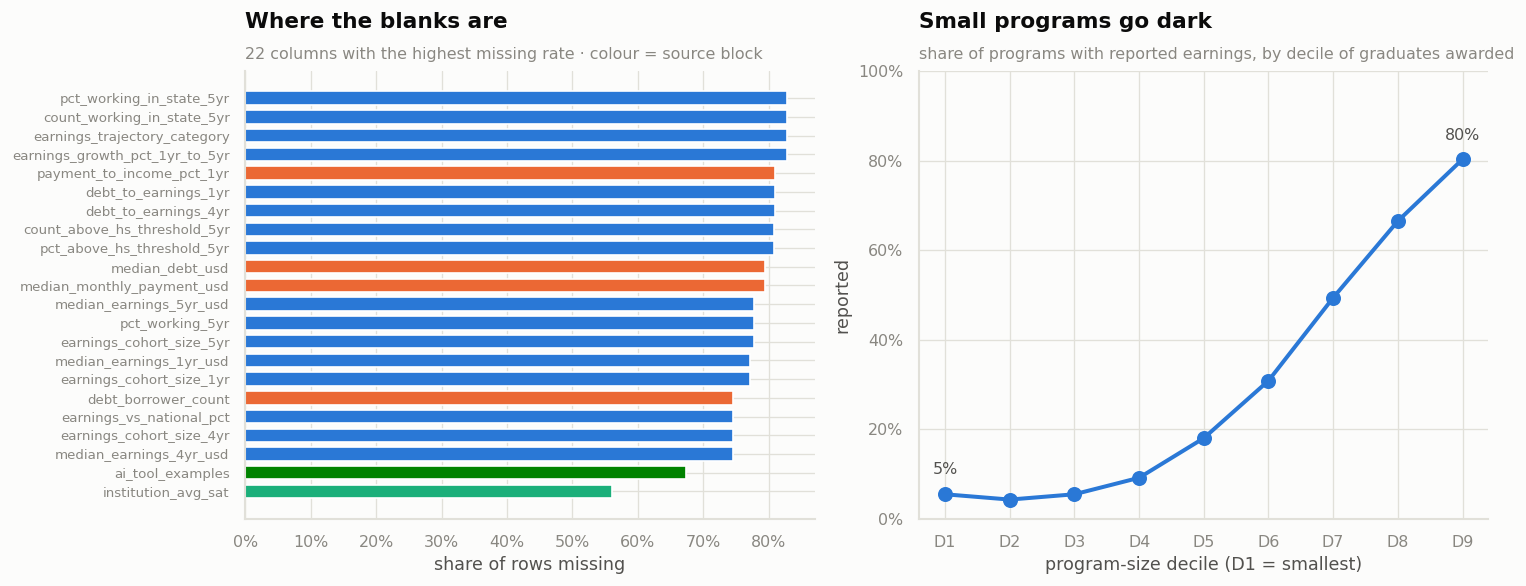

Reported earnings : 58,112 programs (25.5%)
Privacy-suppressed: 169,868 programs


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) how much of each block is missing
miss = (df_raw.isna().mean() * 100).sort_values(ascending=False).head(22)[::-1]
block_of = dict(zip(schema_tbl["column"], schema_tbl["block"]))
order = ["Earnings", "Debt", "Institution", "Program", "Occupation", "AI exposure",
         "Identity", "Status flags"]
colors = [CAT[order.index(block_of.get(c, "Status flags")) % len(CAT)] for c in miss.index]
axes[0].barh(miss.index, miss.values, color=colors, height=0.72)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[0].tick_params(axis="y", labelsize=8)
finish(axes[0], "Where the blanks are",
       "22 columns with the highest missing rate · colour = source block",
       "share of rows missing", "")

# (b) suppression is driven by program size
size_bins = pd.qcut(df_raw["awards_year2"], 10, duplicates="drop")
rate = (df_raw.assign(_b=size_bins, _rep=df_raw["earnings_4yr_status"].eq("reported"))
              .groupby("_b", observed=True)["_rep"].mean())
axes[1].plot(range(len(rate)), rate.values, marker="o", ms=8, lw=2.4, color=CAT[0])
axes[1].set_xticks(range(len(rate)))
axes[1].set_xticklabels([f"D{i+1}" for i in range(len(rate))])
axes[1].yaxis.set_major_formatter(PCT)
axes[1].set_ylim(0, 1)
for i, v in enumerate(rate.values):
    if i in (0, len(rate) - 1):
        axes[1].annotate(f"{v:.0%}", (i, v), textcoords="offset points",
                         xytext=(0, 12), ha="center", color=INK2, fontsize=9.5)
finish(axes[1], "Small programs go dark",
       "share of programs with reported earnings, by decile of graduates awarded",
       "program-size decile (D1 = smallest)", "reported")
plt.tight_layout()
plt.show()

n_rep = df_raw["earnings_4yr_status"].eq("reported").sum()
print(f"Reported earnings : {n_rep:,} programs ({n_rep/len(df_raw):.1%})")
print(f"Privacy-suppressed: {len(df_raw)-n_rep:,} programs")

> **Read this chart.** Missingness rises to roughly 75% overall, and the right-hand panel
> shows why: the smallest decile of programs is reported at a fraction of the rate of the
> largest. **Business meaning:** the Provost's evidence base is systematically biased
> toward large programs. Small, specialised programs — often exactly the ones under review
> for closure — are the ones we know least about. That is the gap the model in §11 fills.

In [ ]:
df = df_raw.copy()

# 1 · duplicates -------------------------------------------------------------
dupes = df.duplicated(subset="program_id").sum()
df = df.drop_duplicates(subset="program_id")

# 2 · type hygiene -----------------------------------------------------------
for c in ["credential_level", "cip_family_code", "is_main_campus",
          "outcomes_shared_across_campuses"]:
    df[c] = df[c].astype("int16")
for c in ["institution_control", "credential_name", "distance_education",
          "cip_family_title", "institution_region",
          "occupation_typical_entry_education", "earnings_trajectory_category"]:
    df[c] = df[c].astype("category")

# 3 · impossible values ------------------------------------------------------
before = len(df)
df = df[(df["median_earnings_4yr_usd"].isna()) | (df["median_earnings_4yr_usd"] > 0)]
df = df[(df["median_debt_usd"].isna()) | (df["median_debt_usd"] > 0)]
df = df[(df["institution_admission_rate"].isna()) |
        df["institution_admission_rate"].between(0, 1)]

# 4 · a categorical for 'is this an online program' --------------------------
df["is_online"] = df["distance_education"].astype(str).str.contains("fully online")

print(f"Duplicate program_id rows dropped : {dupes:,}")
print(f"Impossible-value rows dropped     : {before - len(df):,}")
print(f"Working frame                     : {df.shape[0]:,} x {df.shape[1]}")

Duplicate program_id rows dropped : 0
Impossible-value rows dropped     : 0
Working frame                     : 227,980 x 73


### 4.2 Handling the missing values we *keep*

Three different mechanisms need three different treatments — imputing everything with a
median would be the single worst thing we could do here.

| Group | Example | Treatment | Why |
|---|---|---|---|
| **Suppressed target** | `median_earnings_4yr_usd` | **Never impute. Split the data.** Model is trained on reported rows; suppressed rows become the prediction set. | Imputing a target invents the answer |
| **Structurally absent** | `institution_avg_sat` (56% blank — open-admission schools don't report SAT) | Median-impute *and* add a `_was_missing` flag | The blank itself carries information |
| **Genuinely sparse** | `ai_tool_examples` (67% blank) | Drop from modelling; use only illustratively | Too sparse to model on |

In [ ]:
# The analysis frame: programs whose earnings the Department of Education reported.
ana = df[df["earnings_4yr_status"].eq("reported")].copy()

# The prediction frame: everything the Provost currently cannot see.
hidden = df[df["earnings_4yr_status"].eq("privacy_suppressed")].copy()

print(f"Analysis frame (reported earnings): {len(ana):,} programs")
print(f"Hidden  frame (suppressed)        : {len(hidden):,} programs")
print(f"  ... of which also have debt data: {ana['median_debt_usd'].notna().sum():,}")

Analysis frame (reported earnings): 58,112 programs
Hidden  frame (suppressed)        : 169,868 programs
  ... of which also have debt data: 43,375


### 4.3 Outliers — and whether they bias the conclusion

The project brief asks explicitly whether including outliers leads to biased conclusions,
so we test it rather than assert it. We flag outliers with the standard 1.5·IQR rule but
**do not delete them by default**: a $250k median-earning anaesthesiology program is not a
data error, it is the single most interesting row in the file. We keep both versions and
compare the answers they give in §8.4.

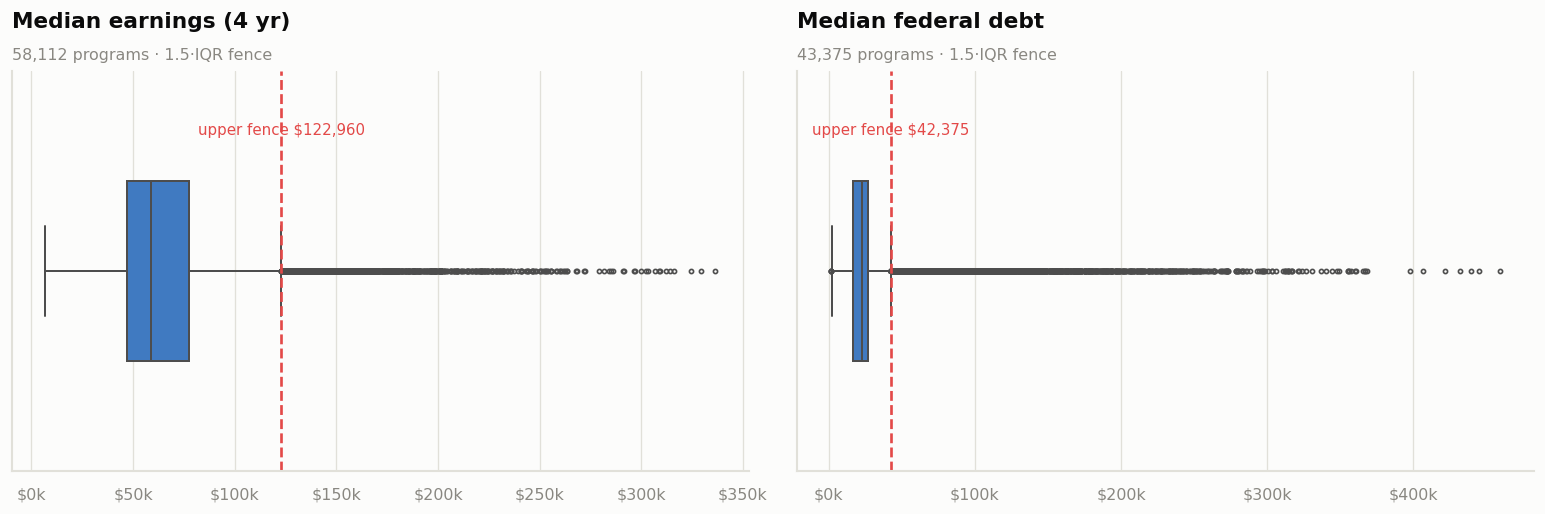

Earnings outliers: 2,279 (3.9%)
Debt outliers    : 4,139 (7.1%)


In [ ]:
def iqr_flags(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr), (q1 - k * iqr, q3 + k * iqr)

ana["earn_outlier"], earn_fence = iqr_flags(ana["median_earnings_4yr_usd"])
ana["debt_outlier"], debt_fence = iqr_flags(ana["median_debt_usd"])
ana["any_outlier"] = ana["earn_outlier"] | ana["debt_outlier"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, col, fence, name in [
        (axes[0], "median_earnings_4yr_usd", earn_fence, "Median earnings (4 yr)"),
        (axes[1], "median_debt_usd",         debt_fence, "Median federal debt")]:
    sns.boxplot(x=ana[col], ax=ax, color=CAT[0], width=0.45,
                fliersize=2.5, linewidth=1.2)
    ax.axvline(fence[1], color=CAT[7], ls="--", lw=1.6)
    ax.annotate(f"upper fence ${fence[1]:,.0f}", (fence[1], -0.34),
                color=CAT[7], fontsize=9, ha="center")
    ax.xaxis.set_major_formatter(USD)
    ax.set_yticks([])
    finish(ax, name, f"{ana[col].notna().sum():,} programs · 1.5·IQR fence", "", "")
plt.tight_layout()
plt.show()

print(f"Earnings outliers: {ana['earn_outlier'].sum():,} "
      f"({ana['earn_outlier'].mean():.1%})")
print(f"Debt outliers    : {ana['debt_outlier'].sum():,} "
      f"({ana['debt_outlier'].mean():.1%})")

> **Read this chart.** Both distributions are strongly right-skewed — a long tail of
> high-earning and high-debt programs. **Business meaning:** the mean is the wrong summary
> statistic for this dataset and we use the median throughout. The tail is where the
> professional degrees live (medicine, dentistry, law), and they carry both the biggest
> paycheques and the biggest loans; §8.4 shows whether excluding them changes the
> recommendation.

## 5 · Feature engineering

Four constructed measures carry most of the analysis. Each one converts a raw column into
something a Provost can act on.

| Feature | Definition | Decision it supports |
|---|---|---|
| `annual_debt_burden` | annual loan payment ÷ annual earnings | Affordability — is this program's debt serviceable? |
| `earnings_premium_pct` | program earnings vs. the linked occupation's national median wage | Does *this* program beat the occupation's typical pay? |
| `ai_exposure_index` | 0–1 blend of four O*NET AI signals | Exposure of the destination occupation to AI tooling |
| `roi_tier` | banded debt-to-earnings ratio | The four-way action category |

The debt-to-earnings bands follow the federal gainful-employment convention: below 0.30 is
comfortably serviceable, above 1.0 means a graduate owes more than a full year's earnings.

In [ ]:
HS_MEDIAN_EARNINGS = 45_000     # BLS median for a US high-school graduate, ~2024 (assumption)

# 1 · affordability ----------------------------------------------------------
ana["annual_loan_payment_usd"] = ana["median_monthly_payment_usd"] * 12
ana["annual_debt_burden"] = (ana["annual_loan_payment_usd"]
                             / ana["median_earnings_4yr_usd"])

# 2 · does the program beat its occupation's national wage? ------------------
ana["earnings_premium_pct"] = ((ana["median_earnings_4yr_usd"]
                                - ana["occupation_median_wage_2024_usd"])
                               / ana["occupation_median_wage_2024_usd"] * 100)

# 3 · years to repay out of the earnings premium over a HS diploma -----------
gain = (ana["median_earnings_4yr_usd"] - HS_MEDIAN_EARNINGS).clip(lower=1)
ana["payback_years"] = (ana["median_debt_usd"] / gain).clip(upper=40)

# 4 · AI exposure index: min-max each signal, then average what is present ----
AI_SIGNALS = ["ai_software_occupation_share", "expert_system_occupation_share",
              "ai_tools_max_per_occupation", "hot_technologies_mean_per_occupation"]

def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0

for frame in (ana, hidden):
    scaled = pd.DataFrame({c: minmax(frame[c]) for c in AI_SIGNALS})
    frame["ai_exposure_index"] = scaled.mean(axis=1, skipna=True)

# 5 · the four-way action category -------------------------------------------
ana["roi_tier"] = pd.cut(
    ana["debt_to_earnings_4yr"],
    bins=[-0.001, 0.30, 0.60, 1.00, np.inf],
    labels=["Strong (<0.30)", "Moderate (0.30-0.60)",
            "Stretched (0.60-1.00)", "At risk (>1.00)"])

TIER_COLORS = {"Strong (<0.30)": "#0ca30c", "Moderate (0.30-0.60)": "#2a78d6",
               "Stretched (0.60-1.00)": "#eda100", "At risk (>1.00)": "#d03b3b"}

print(ana[["annual_debt_burden", "earnings_premium_pct",
           "payback_years", "ai_exposure_index"]].describe().T.round(3))
print()
print(ana["roi_tier"].value_counts().sort_index().to_string())

                        count    mean     std     min     25%     50%    75%  \
annual_debt_burden    43375.0   0.055   0.039   0.004   0.034   0.046  0.064   
earnings_premium_pct  57267.0 -23.461  28.859 -89.381 -43.169 -27.148 -9.235   
payback_years         43375.0   9.962  15.445   0.038   0.760   1.681  7.148   
ai_exposure_index     55634.0   0.113   0.169   0.000   0.013   0.034  0.160   

                          max  
annual_debt_burden      0.786  
earnings_premium_pct  357.122  
payback_years          40.000  
ai_exposure_index       0.829  

roi_tier
Strong (<0.30)           15381
Moderate (0.30-0.60)     22077
Stretched (0.60-1.00)     4411
At risk (>1.00)           1506


## 6 · Exploratory analysis, layer 1 — distributions

Three layers, deliberately. Layer 1 asks *what does one variable look like*, layer 2 asks
*how do two move together*, layer 3 asks *what does the whole picture say*. Skipping to
layer 3 is how people end up presenting a beautiful chart of an artefact.

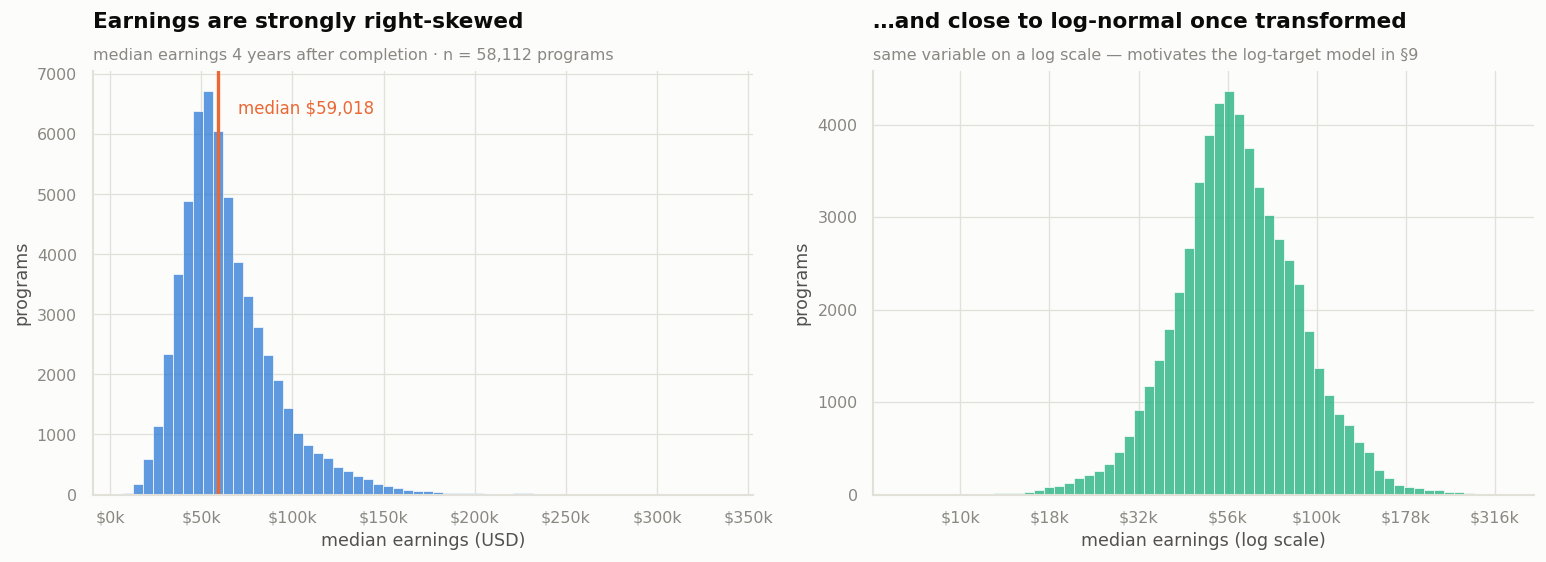

Skew (raw): 1.76   Skew (log): 0.02


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

e = ana["median_earnings_4yr_usd"].dropna()
sns.histplot(e, bins=60, color=CAT[0], ax=axes[0], edgecolor="white", linewidth=0.4)
axes[0].axvline(e.median(), color=CAT[1], lw=2)
axes[0].annotate(f"median ${e.median():,.0f}", (e.median(), axes[0].get_ylim()[1] * 0.9),
                 xytext=(12, 0), textcoords="offset points", color=CAT[1], fontsize=10)
axes[0].xaxis.set_major_formatter(USD)
finish(axes[0], "Earnings are strongly right-skewed",
       f"median earnings 4 years after completion · n = {len(e):,} programs",
       "median earnings (USD)", "programs")

sns.histplot(np.log10(e), bins=60, color=CAT[2], ax=axes[1],
             edgecolor="white", linewidth=0.4)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${10**v/1000:,.0f}k"))
finish(axes[1], "…and close to log-normal once transformed",
       "same variable on a log scale — motivates the log-target model in §9",
       "median earnings (log scale)", "programs")
plt.tight_layout()
plt.show()

print(f"Skew (raw): {e.skew():.2f}   Skew (log): {np.log(e).skew():.2f}")

> **Read this chart.** Raw earnings have a heavy right tail (skew well above 1); the log
> transform pulls it close to symmetric. **Business meaning:** report medians, not means,
> in anything that reaches the Provost — and in §9 we fit a log-target linear model
> alongside the raw one, because a linear model on the raw scale will systematically
> under-predict the high end.

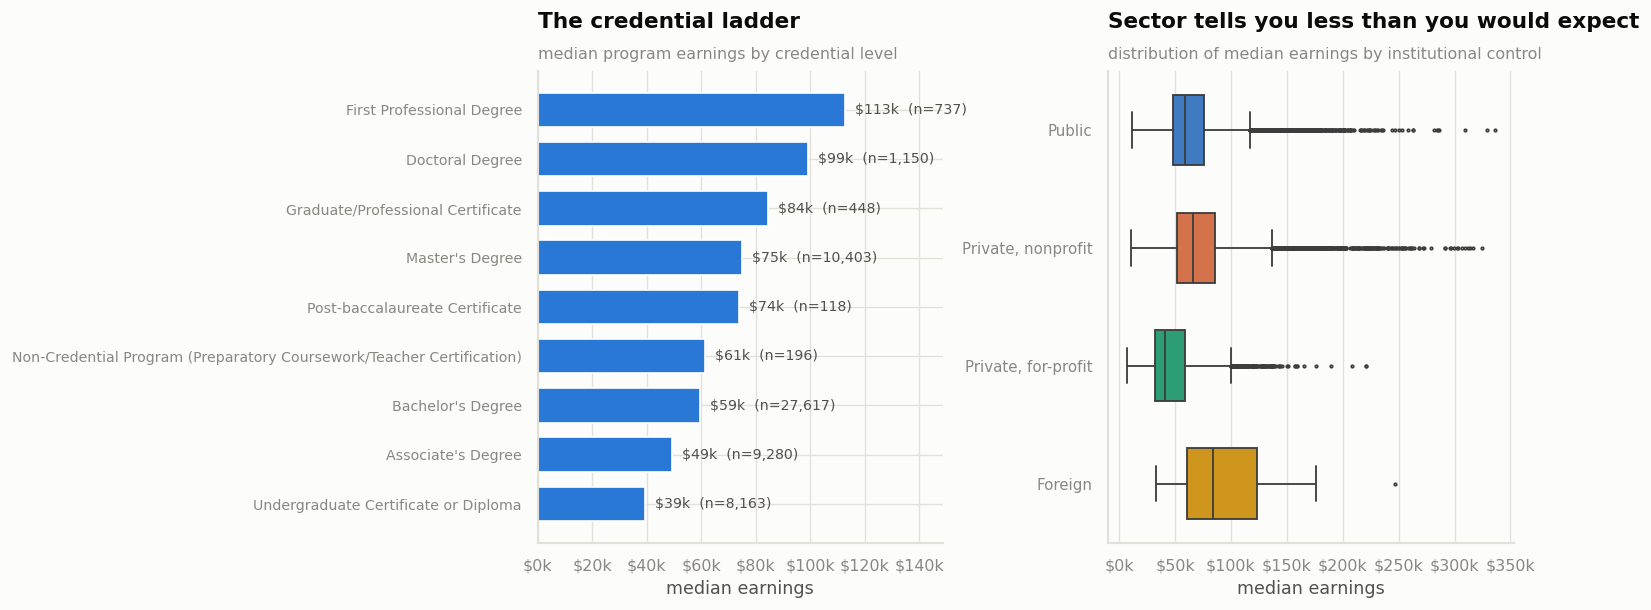

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

cred = (ana.groupby("credential_name", observed=True)
           .agg(n=("program_id", "size"),
                med=("median_earnings_4yr_usd", "median"))
           .sort_values("med"))
axes[0].barh(cred.index, cred["med"], color=CAT[0], height=0.7)
for y, (n, m) in enumerate(zip(cred["n"], cred["med"])):
    axes[0].annotate(f"${m/1000:,.0f}k  (n={n:,})", (m, y), xytext=(6, 0),
                     textcoords="offset points", va="center",
                     color=INK2, fontsize=8.5)
axes[0].xaxis.set_major_formatter(USD)
axes[0].set_xlim(0, cred["med"].max() * 1.32)
axes[0].tick_params(axis="y", labelsize=8.5)
finish(axes[0], "The credential ladder", "median program earnings by credential level",
       "median earnings", "")

ctrl = ana["institution_control"].value_counts()
sns.boxplot(data=ana, y="institution_control", x="median_earnings_4yr_usd",
            ax=axes[1], palette=CAT[:4], width=0.6, fliersize=1.5, linewidth=1.1,
            order=ctrl.index)
axes[1].xaxis.set_major_formatter(USD)
axes[1].tick_params(axis="y", labelsize=9)
finish(axes[1], "Sector tells you less than you would expect",
       "distribution of median earnings by institutional control",
       "median earnings", "")
plt.tight_layout()
plt.show()

> **Read this chart.** The credential ladder is monotonic and steep — each rung adds real
> money, and first-professional/doctoral programs sit far above the rest. Sector (public
> vs. private) produces heavily overlapping distributions by comparison.
> **Business meaning:** for the Provost, *what level you offer a program at* is a bigger
> earnings lever than *what kind of institution you are*. A department debating whether to
> add a master's track is arguing about a larger effect than one debating its sector
> positioning.

## 7 · Exploratory analysis, layer 2 — relationships

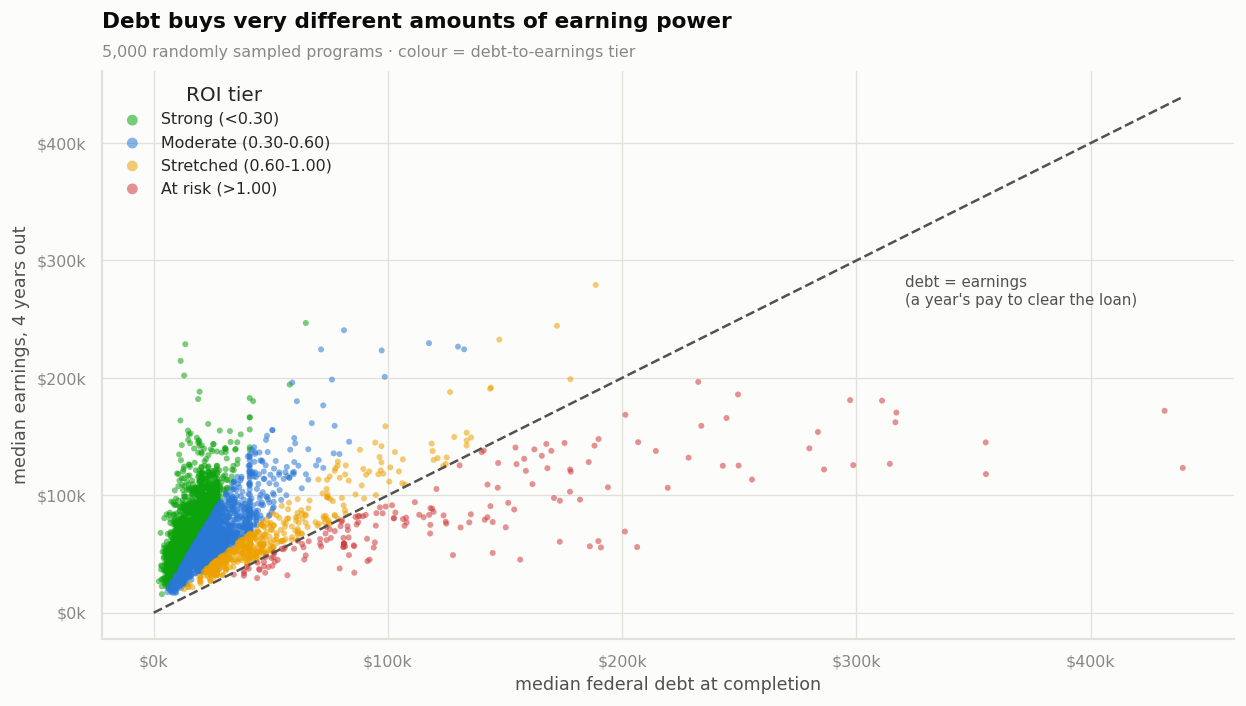

Correlation(debt, earnings) = 0.447


In [ ]:
plot_df = ana.dropna(subset=["median_debt_usd", "median_earnings_4yr_usd"])
samp = plot_df.sample(min(5000, len(plot_df)), random_state=RANDOM_STATE)  # readable scatter

fig, ax = plt.subplots(figsize=(10.5, 6))
for i, (tier, g) in enumerate(samp.groupby("roi_tier", observed=True)):
    ax.scatter(g["median_debt_usd"], g["median_earnings_4yr_usd"], s=13, alpha=0.55,
               color=TIER_COLORS.get(tier, CAT[i]), label=tier,
               edgecolors="none")
lim = np.linspace(0, samp["median_debt_usd"].max(), 100)
ax.plot(lim, lim, color=INK2, ls="--", lw=1.5)
ax.annotate("debt = earnings\n(a year's pay to clear the loan)",
            (lim[70], lim[70]), xytext=(14, -34), textcoords="offset points",
            color=INK2, fontsize=9)
ax.xaxis.set_major_formatter(USD)
ax.yaxis.set_major_formatter(USD)
ax.legend(loc="upper left", markerscale=1.8)
finish(ax, "Debt buys very different amounts of earning power",
       f"{len(samp):,} randomly sampled programs · colour = debt-to-earnings tier",
       "median federal debt at completion", "median earnings, 4 years out",
       legend_title="ROI tier")
plt.tight_layout()
plt.show()

r = plot_df["median_debt_usd"].corr(plot_df["median_earnings_4yr_usd"])
print(f"Correlation(debt, earnings) = {r:.3f}")

> **Read this chart.** The cloud sits mostly above the 45° line — most programs return more
> than a year's earnings for the debt taken on — but a visible band of red points sits
> below it. The debt–earnings correlation is positive yet far from tight, which is the
> whole point: **debt is a poor proxy for value.**
> **Business meaning:** cost of attendance cannot be used as a quality signal in advising
> materials. The ROI tier has to be computed program by program.

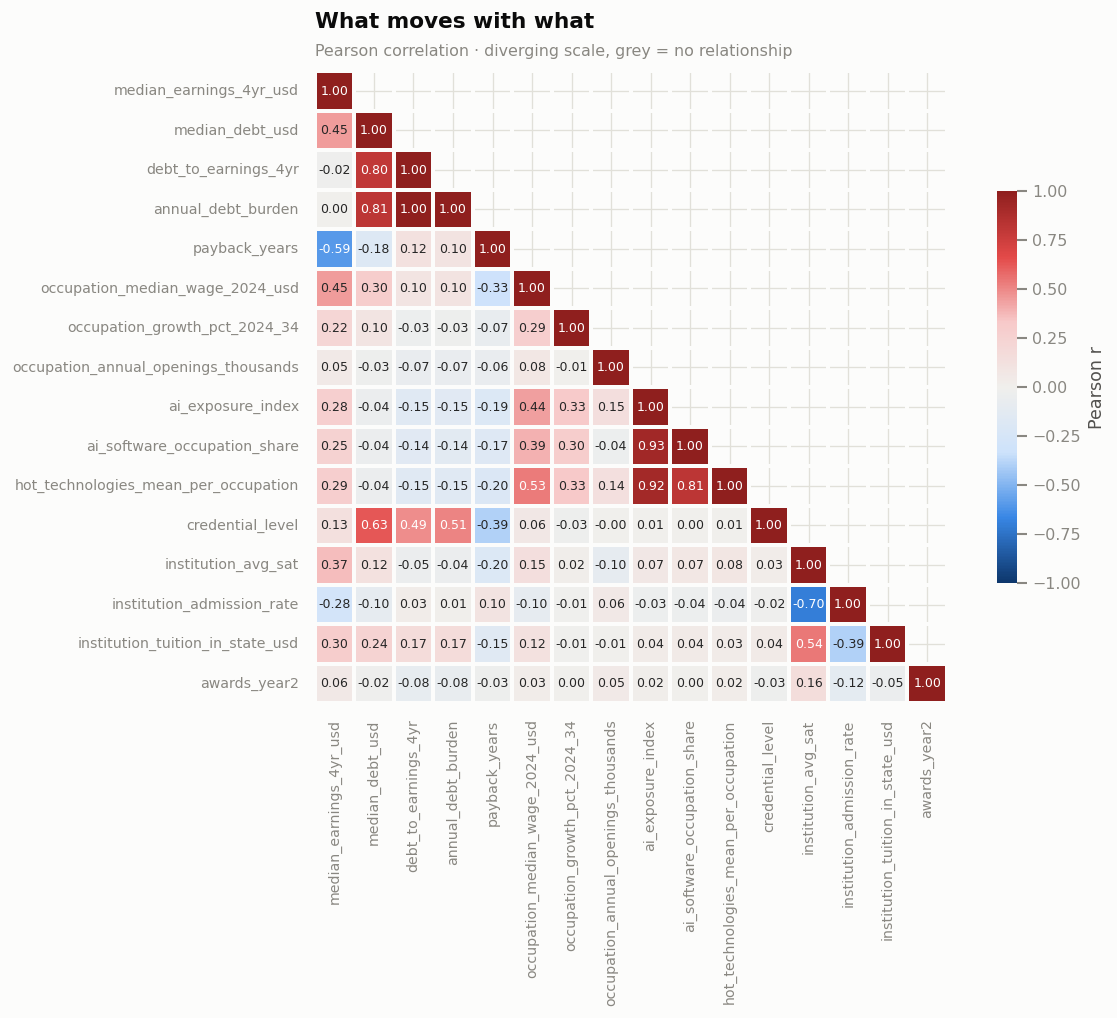

Strongest correlates of median earnings:
payback_years                           0.594
occupation_median_wage_2024_usd         0.449
median_debt_usd                         0.447
institution_avg_sat                     0.366
institution_tuition_in_state_usd        0.301
hot_technologies_mean_per_occupation    0.288


In [ ]:
CORR_COLS = ["median_earnings_4yr_usd", "median_debt_usd", "debt_to_earnings_4yr",
             "annual_debt_burden", "payback_years", "occupation_median_wage_2024_usd",
             "occupation_growth_pct_2024_34", "occupation_annual_openings_thousands",
             "ai_exposure_index", "ai_software_occupation_share",
             "hot_technologies_mean_per_occupation", "credential_level",
             "institution_avg_sat", "institution_admission_rate",
             "institution_tuition_in_state_usd", "awards_year2"]
CORR_COLS = [c for c in CORR_COLS if c in ana.columns]

corr = ana[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8.6))
sns.heatmap(corr, mask=mask, cmap=DIV, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7.5},
            linewidths=1.4, linecolor=SURFACE, square=True,
            cbar_kws={"shrink": 0.62, "label": "Pearson r"}, ax=ax)
ax.tick_params(labelsize=8.5)
finish(ax, "What moves with what",
       "Pearson correlation · diverging scale, grey = no relationship")
plt.tight_layout()
plt.show()

print("Strongest correlates of median earnings:")
print(corr["median_earnings_4yr_usd"].drop("median_earnings_4yr_usd")
          .abs().sort_values(ascending=False).head(6).round(3).to_string())

> **Read this chart.** The strongest single correlate of program earnings is the linked
> occupation's national median wage — an *external* BLS figure, not anything about the
> school. Credential level and institutional selectivity follow. The AI signals correlate
> only weakly with earnings, which is itself the headline for §8.3.
> **Business meaning:** most of a program's earnings outcome is set by *where its graduates
> work*, not by the institution. The Provost's lever is therefore programme portfolio and
> occupational alignment, not marketing.

## 8 · Exploratory analysis, layer 3 — the whole picture

### 8.1 Which fields pay, and which fields borrow

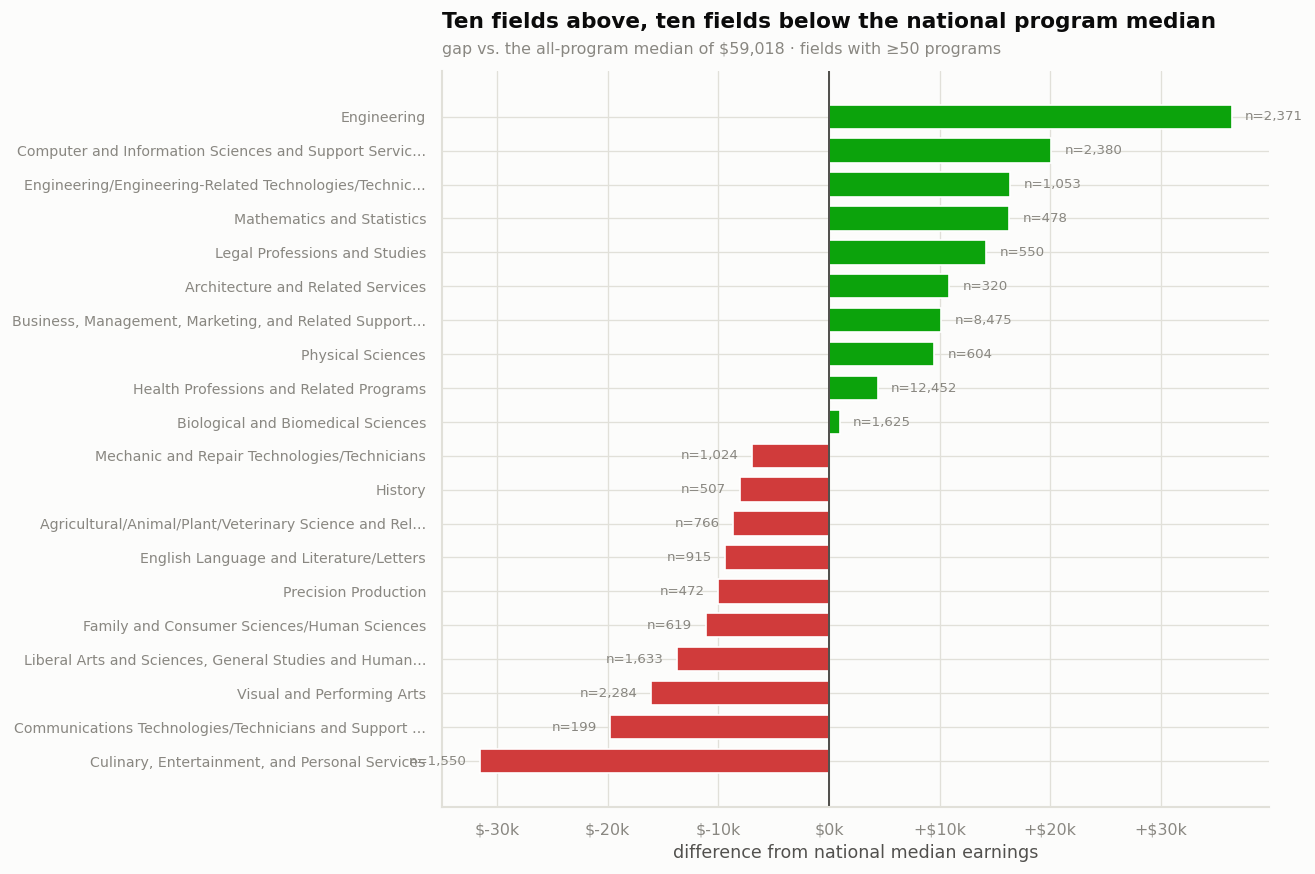

In [ ]:
fam = (ana.groupby("cip_family_title", observed=True)
          .agg(n=("program_id", "size"),
               grads=("awards_year2", "sum"),
               earn=("median_earnings_4yr_usd", "median"),
               debt=("median_debt_usd", "median"))
          .query("n >= 50"))
national = ana["median_earnings_4yr_usd"].median()
fam["gap"] = fam["earn"] - national
fam = fam.sort_values("gap")
show = pd.concat([fam.head(10), fam.tail(10)])

fig, ax = plt.subplots(figsize=(11, 7.4))
cols = [("#d03b3b" if g < 0 else "#0ca30c") for g in show["gap"]]
ax.barh(range(len(show)), show["gap"], color=cols, height=0.72)
ax.set_yticks(range(len(show)))
ax.set_yticklabels([t[:52] + ("…" if len(t) > 52 else "") for t in show.index], fontsize=8.5)
ax.axvline(0, color=INK2, lw=1.2)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{'+' if v>0 else ''}${v/1000:,.0f}k"))
for y, (g, n) in enumerate(zip(show["gap"], show["n"])):
    ax.annotate(f"n={n:,}", (g, y), xytext=(8 if g > 0 else -8, 0),
                textcoords="offset points", va="center",
                ha="left" if g > 0 else "right", color=MUTED, fontsize=8)
finish(ax, "Ten fields above, ten fields below the national program median",
       f"gap vs. the all-program median of ${national:,.0f} · fields with ≥50 programs",
       "difference from national median earnings", "")
plt.tight_layout()
plt.show()

> **Read this chart.** The spread between the top and bottom field is on the order of a
> whole national median — the choice of field matters enormously in the tails, even though
> §6 showed credential level dominates on average.
> **Business meaning:** this is the shortlist a Provost starts from. Fields on the red end
> with large enrolment are where debt-to-earnings problems concentrate; fields on the green
> end with small enrolment are candidates for expansion.

### 8.2 Field × credential — where the money actually is

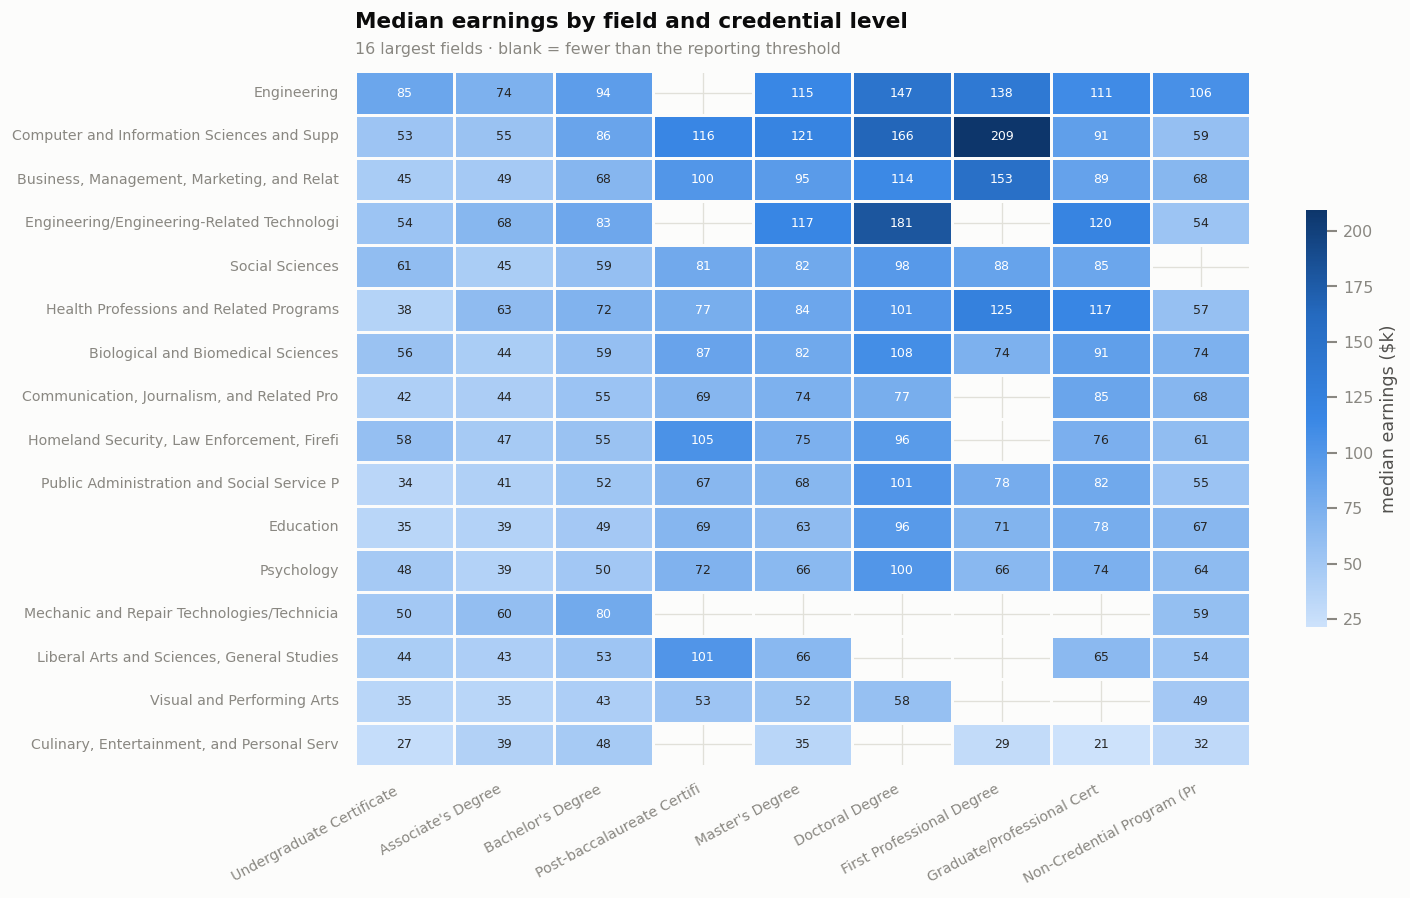

In [ ]:
top_fams = ana["cip_family_title"].value_counts().head(16).index
cred_order = (ana.groupby("credential_name", observed=True)["credential_level"]
                 .first().sort_values().index)

pivot = (ana[ana["cip_family_title"].isin(top_fams)]
         .pivot_table(index="cip_family_title", columns="credential_name",
                      values="median_earnings_4yr_usd", aggfunc="median",
                      observed=True)
         .reindex(columns=[c for c in cred_order if c in ana["credential_name"].unique()]))
pivot = pivot.loc[pivot.median(axis=1).sort_values(ascending=False).index]
pivot = pivot.dropna(axis=1, how="all")

fig, ax = plt.subplots(figsize=(12.5, 7.6))
sns.heatmap(pivot / 1000, cmap=SEQ, annot=True, fmt=".0f", annot_kws={"size": 7.5},
            linewidths=1.6, linecolor=SURFACE,
            cbar_kws={"shrink": 0.6, "label": "median earnings ($k)"}, ax=ax)
ax.set_yticklabels([t.get_text()[:42] for t in ax.get_yticklabels()],
                   fontsize=8.5, rotation=0)
ax.set_xticklabels([t.get_text()[:26] for t in ax.get_xticklabels()],
                   fontsize=8.5, rotation=28, ha="right")
finish(ax, "Median earnings by field and credential level",
       "16 largest fields · blank = fewer than the reporting threshold", "", "")
plt.tight_layout()
plt.show()

> **Read this chart.** Reading across a row shows what an extra credential level is worth
> *within* a field — and the increment is wildly uneven. Some fields reward a master's
> substantially; in others the row is nearly flat.
> **Business meaning:** this is the single most directly actionable exhibit in the deck. A
> flat row says "a graduate track here will not move graduate outcomes"; a steep row says
> "this is where a new master's programme pays for itself." That is a concrete answer to
> *where should we invest*.

### 8.3 The AI exposure map — the quadrant the Provost should be looking at

This is the exhibit built for the 2026 conversation. Each bubble is a field of study,
positioned by how exposed its destination occupations are to AI tooling (x) and how much
its graduates earn relative to the national program median (y), sized by graduates
produced.

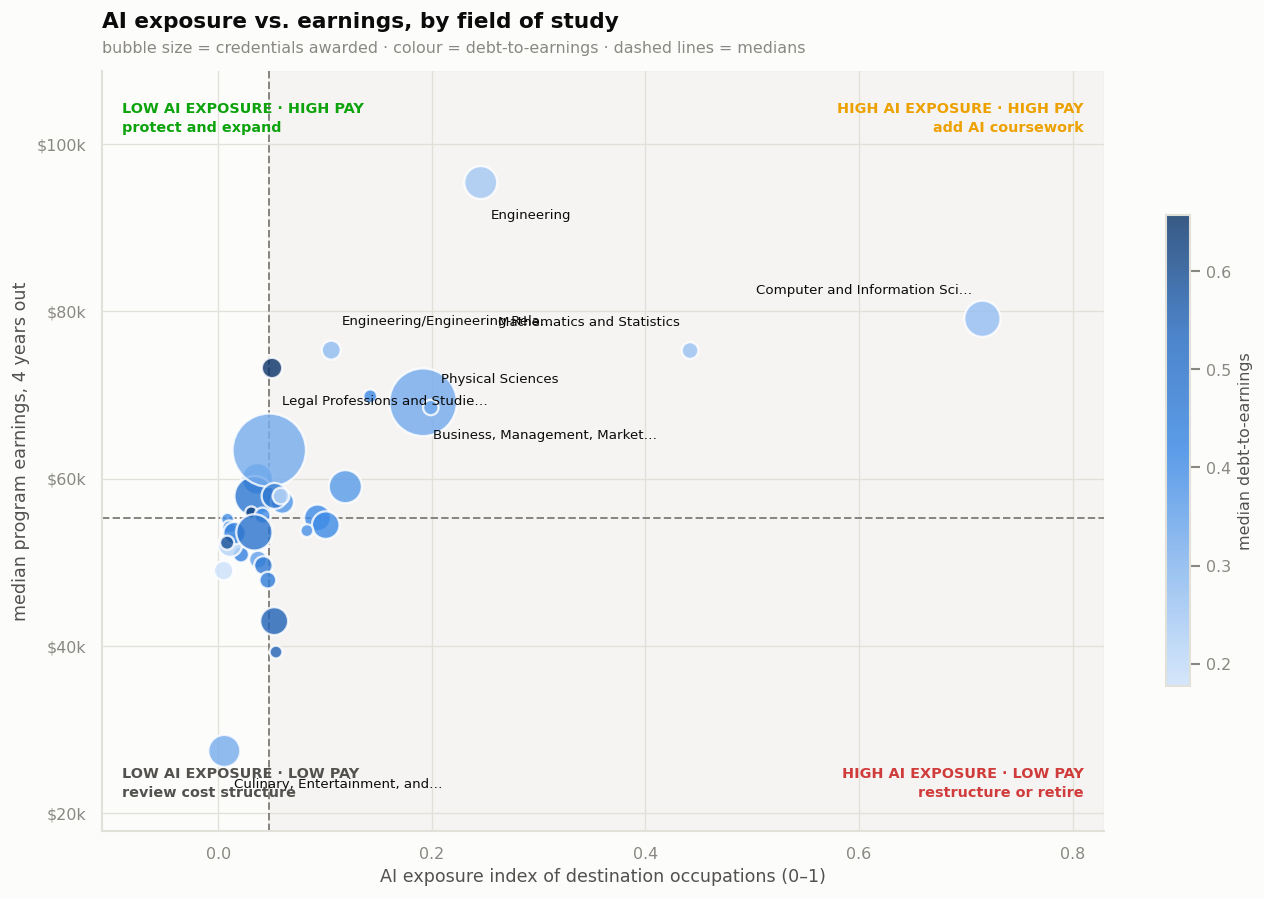

Fields in the 'high pay, high AI exposure' quadrant: 12
They account for 40.6% of all credentials awarded.


In [ ]:
q = (ana.groupby("cip_family_title", observed=True)
        .agg(earn=("median_earnings_4yr_usd", "median"),
             ai=("ai_exposure_index", "mean"),
             grads=("awards_year2", "sum"),
             n=("program_id", "size"),
             de=("debt_to_earnings_4yr", "median"))
        .query("n >= 50").dropna(subset=["ai", "earn"]))
xm, ym = q["ai"].median(), q["earn"].median()

fig, ax = plt.subplots(figsize=(11.5, 7.6))

# fix the axis limits first so the quadrant shading and the labels both fit
xpad = (q["ai"].max() - q["ai"].min()) * 0.16 or 0.02
ypad = (q["earn"].max() - q["earn"].min()) * 0.14 or 1000
xlo, xhi = q["ai"].min() - xpad, q["ai"].max() + xpad
ylo, yhi = q["earn"].min() - ypad, q["earn"].max() + ypad * 1.4
ax.set_xlim(xlo, xhi)
ax.set_ylim(ylo, yhi)

ax.axvspan(xm, xhi, color="#f0efec", alpha=0.55, zorder=0)
ax.axvline(xm, color=MUTED, ls="--", lw=1.2, zorder=1)
ax.axhline(ym, color=MUTED, ls="--", lw=1.2, zorder=1)

sizes = 40 + 1900 * (q["grads"] / q["grads"].max())
sc = ax.scatter(q["ai"], q["earn"], s=sizes, c=q["de"], cmap=SEQ,
                alpha=0.82, edgecolors="white", linewidths=1.4, zorder=3)
cb = plt.colorbar(sc, ax=ax, shrink=0.62)
cb.set_label("median debt-to-earnings", color=INK2, fontsize=9.5)

# Label only the most extreme fields — a label on every bubble is unreadable.
# Offsets alternate above/below so neighbouring labels do not collide.
q = q.assign(_d=((q["ai"] - xm) / q["ai"].std()) ** 2 + ((q["earn"] - ym) / q["earn"].std()) ** 2)
for k, (name, row) in enumerate(q.nlargest(8, "_d").iterrows()):
    dy = 15 if k % 2 == 0 else -22
    ha = "left" if row["ai"] < (xlo + xhi) / 2 else "right"
    ax.annotate(name[:28] + ("…" if len(name) > 28 else ""),
                (row["ai"], row["earn"]), xytext=(6 if ha == "left" else -6, dy),
                textcoords="offset points", ha=ha, fontsize=8,
                color=INK, zorder=4)

for (xf, yf, txt, col) in [(0.02, 0.96, "LOW AI EXPOSURE · HIGH PAY\nprotect and expand", "#0ca30c"),
                           (0.98, 0.96, "HIGH AI EXPOSURE · HIGH PAY\nadd AI coursework", "#eda100"),
                           (0.02, 0.04, "LOW AI EXPOSURE · LOW PAY\nreview cost structure", "#52514e"),
                           (0.98, 0.04, "HIGH AI EXPOSURE · LOW PAY\nrestructure or retire", "#d03b3b")]:
    ax.text(xf, yf, txt, transform=ax.transAxes, fontsize=8.6, color=col,
            ha="left" if xf < 0.5 else "right", va="top" if yf > 0.5 else "bottom",
            linespacing=1.5, fontweight="semibold", zorder=5)

ax.yaxis.set_major_formatter(USD)
finish(ax, "AI exposure vs. earnings, by field of study",
       "bubble size = credentials awarded · colour = debt-to-earnings · dashed lines = medians",
       "AI exposure index of destination occupations (0–1)",
       "median program earnings, 4 years out")
plt.tight_layout()
plt.show()

hi_ai_hi_pay = q[(q["ai"] > xm) & (q["earn"] > ym)]
print(f"Fields in the 'high pay, high AI exposure' quadrant: {len(hi_ai_hi_pay)}")
print(f"They account for {hi_ai_hi_pay['grads'].sum()/q['grads'].sum():.1%} of all credentials awarded.")

> **Read this chart.** The top-right quadrant is the one that should worry a Provost: fields
> that pay well *today* and whose destination occupations already show heavy AI-tool
> adoption. The bottom-right — low pay *and* high exposure — is where restructuring
> conversations belong.
> **Business meaning:** this single exhibit converts an abstract "AI is coming" anxiety into
> a named list of programs and a specific intervention for each quadrant. Note the
> interpretation limit: high AI-tool adoption in an occupation means *AI is being used
> there*, which can mean augmentation as easily as displacement. We treat it as an exposure
> flag warranting curriculum attention, not a prediction of job loss.

### 8.4 Does the debt burden concentrate? And do the outliers change the answer?

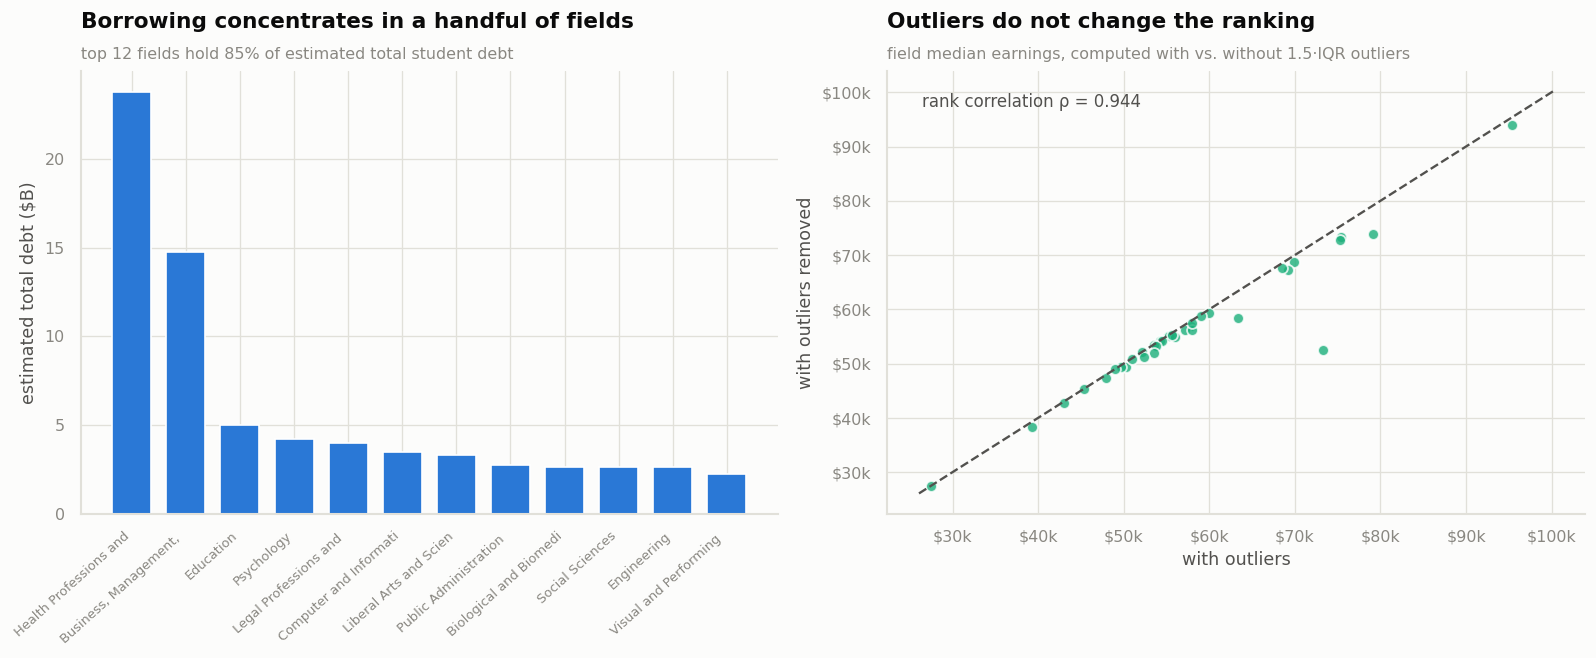

Spearman rank correlation of field rankings: 0.9441
Programs excluded as outliers: 5,477 (9.4%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))

# (a) Pareto: where the borrowed money sits
p = (ana.dropna(subset=["median_debt_usd", "awards_year2"])
        .assign(total_debt=lambda d: d["median_debt_usd"] * d["awards_year2"])
        .groupby("cip_family_title", observed=True)["total_debt"].sum()
        .sort_values(ascending=False))
p = p[p > 0]
top = p.head(12)
cum = p.cumsum() / p.sum()

ax = axes[0]
ax.bar(range(len(top)), top.values / 1e9, color=CAT[0], width=0.72)
ax.set_xticks(range(len(top)))
ax.set_xticklabels([t[:22] for t in top.index], rotation=42, ha="right", fontsize=7.8)
ax.set_ylabel("estimated total debt ($B)")
# Deliberately NOT a dual-axis Pareto: the cumulative share goes in the subtitle
# instead of a second y-scale, which is the single most misread chart form there is.
finish(ax, "Borrowing concentrates in a handful of fields",
       f"top 12 fields hold {cum.iloc[11]:.0%} of estimated total student debt",
       "", "estimated total debt ($B)")

# (b) does dropping outliers change the field ranking?
def field_medians(frame):
    return (frame.groupby("cip_family_title", observed=True)["median_earnings_4yr_usd"]
                 .median())
with_o = field_medians(ana)
without_o = field_medians(ana[~ana["any_outlier"]])
cmp = pd.concat([with_o.rename("with"), without_o.rename("without")], axis=1).dropna()
cmp = cmp[ana["cip_family_title"].value_counts().reindex(cmp.index).ge(50).values]

ax = axes[1]
ax.scatter(cmp["with"], cmp["without"], s=42, color=CAT[2], alpha=0.8,
           edgecolors="white", linewidths=1.1)
lo, hi = cmp.min().min() * 0.95, cmp.max().max() * 1.05
ax.plot([lo, hi], [lo, hi], color=INK2, ls="--", lw=1.4)
ax.xaxis.set_major_formatter(USD)
ax.yaxis.set_major_formatter(USD)
rho = cmp["with"].corr(cmp["without"], method="spearman")
ax.annotate(f"rank correlation ρ = {rho:.3f}", (0.05, 0.92), xycoords="axes fraction",
            color=INK2, fontsize=10)
finish(ax, "Outliers do not change the ranking",
       "field median earnings, computed with vs. without 1.5·IQR outliers",
       "with outliers", "with outliers removed")
plt.tight_layout()
plt.show()

print(f"Spearman rank correlation of field rankings: {rho:.4f}")
print(f"Programs excluded as outliers: {ana['any_outlier'].sum():,} "
      f"({ana['any_outlier'].mean():.1%})")

> **Read this chart.** Left: borrowing is heavily concentrated — a dozen fields hold the
> large majority of estimated total debt, so debt policy is a *targeted* problem, not a
> universal one. Right: removing outliers barely perturbs the field ranking (ρ very close
> to 1).
> **Business meaning:** this is the direct answer to the brief's question about outlier
> bias — **for the conclusions we draw, it does not matter.** The outliers are real
> high-value programs, so we keep them, and we can say so with evidence rather than
> assertion.

## 9 · Predictive modelling

### 9.1 Framing — and why the feature list is constrained

We predict `median_earnings_4yr_usd` for a program. The business purpose is *not* to
re-report a number the Department of Education already published: it is to **estimate
earnings for the 74.5% of programs where that number is suppressed** (§11).

That purpose imposes a hard constraint that shapes everything: **every feature must be
available for a suppressed program.** So we exclude, on principle:

- anything arithmetically derived from the target — `earnings_vs_national_pct`,
  `debt_to_earnings_4yr`, `payback_years`, the 1-year and 5-year earnings columns;
- anything suppressed alongside the target — `median_debt_usd`, cohort sizes,
  `pct_working_5yr`. These are excellent predictors and completely useless to us, because
  they are blank in exactly the rows we want to score.

What survives is three clean blocks: **institution** characteristics, **program taxonomy**,
and **BLS/O\*NET occupation** data. A model built on those can score every program in the
catalogue.

> Skipping this step is the classic failure mode: a model with R² of 0.97 that cannot be
> applied to a single row you actually care about.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TARGET = "median_earnings_4yr_usd"

NUM_FEATURES = [
    # institution
    "institution_admission_rate", "institution_avg_sat",
    "institution_undergrad_enrollment", "institution_tuition_in_state_usd",
    "institution_tuition_out_state_usd", "is_main_campus", "institution_is_hbcu",
    # program
    "credential_level", "awards_year1", "awards_year2",
    # occupation (BLS)
    "occupation_employment_2024_thousands", "occupation_growth_pct_2024_34",
    "occupation_growth_pct_max", "occupation_annual_openings_thousands",
    "occupation_median_wage_2024_usd", "linked_occupations_count",
    "linked_occupations_in_bls", "linked_occupations_in_onet",
    # AI exposure (O*NET)
    "occupations_using_ai_software", "ai_software_occupation_share",
    "expert_system_occupation_share", "ai_tools_max_per_occupation",
    "hot_technologies_mean_per_occupation", "ai_exposure_index",
]
CAT_FEATURES = ["institution_control", "institution_region", "credential_name",
                "distance_education", "occupation_typical_entry_education",
                "cip_family_title"]

NUM_FEATURES = [c for c in NUM_FEATURES if c in ana.columns]
CAT_FEATURES = [c for c in CAT_FEATURES if c in ana.columns]

# Keep the 20 biggest fields as their own dummies; everything else -> "Other",
# so the tree stays readable and we do not fit 49 near-empty indicators.
TOP_FAMS = ana["cip_family_title"].value_counts().head(20).index

def build_matrix(frame):
    X = frame[NUM_FEATURES].copy()
    cats = frame[CAT_FEATURES].astype(str).copy()
    cats["cip_family_title"] = np.where(
        cats["cip_family_title"].isin(TOP_FAMS), cats["cip_family_title"], "Other field")
    # a missing SAT is information (open-admission schools), not noise
    X["sat_missing"] = frame["institution_avg_sat"].isna().astype(int)
    X["admit_missing"] = frame["institution_admission_rate"].isna().astype(int)
    return pd.concat([X, pd.get_dummies(cats, drop_first=True, dtype=float)], axis=1)

model_df = ana.dropna(subset=[TARGET]).copy()

# The brief suggests sampling when a dataset is large; cap the training frame so the
# notebook re-runs in a couple of minutes on a free Colab CPU runtime.
MODEL_SAMPLE_N = 40_000
if len(model_df) > MODEL_SAMPLE_N:
    model_df = model_df.sample(MODEL_SAMPLE_N, random_state=RANDOM_STATE)
    print(f"Sampled {MODEL_SAMPLE_N:,} programs for modelling.")

X_all = build_matrix(model_df)
y_all = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE)

# Impute with TRAIN medians only — computing them on the full data would leak
# test-set information into training.
med = X_train.median()
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

print(f"Training programs: {len(X_train):,}   Test programs: {len(X_test):,}")
print(f"Features after encoding: {X_train.shape[1]}")

Sampled 40,000 programs for modelling.
Training programs: 32,000   Test programs: 8,000
Features after encoding: 77


### 9.2 A ladder of four models

Each rung buys something the previous one lacked: interpretable coefficients → a corrected
functional form → explicit non-linear rules → ensemble accuracy.

In [ ]:
def score(name, y_true, y_pred):
    return {"Model": name,
            "R²": r2_score(y_true, y_pred),
            "RMSE ($)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE ($)": mean_absolute_error(y_true, y_pred)}

results, fitted = [], {}

# 1 · Linear regression — the interpretable baseline
lin = LinearRegression().fit(X_train, y_train)
results.append(score("Linear regression", y_test, lin.predict(X_test)))
fitted["Linear regression"] = lin

# 2 · Linear regression on a log target — §6 showed the target is log-normal.
#     Metrics are computed after back-transforming, so they stay comparable.
lin_log = LinearRegression().fit(X_train, np.log(y_train))
results.append(score("Linear regression (log target)",
                     y_test, np.exp(lin_log.predict(X_test))))
fitted["Linear regression (log target)"] = lin_log

# 3 · Decision tree — depth-limited so it can be read as business rules
tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=50,
                             random_state=RANDOM_STATE).fit(X_train, y_train)
results.append(score("Decision tree (depth 4)", y_test, tree.predict(X_test)))
fitted["Decision tree (depth 4)"] = tree

# 4 · Random forest — the accuracy rung
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                           random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
results.append(score("Random forest (200 trees)", y_test, rf.predict(X_test)))
fitted["Random forest (200 trees)"] = rf

res = pd.DataFrame(results).set_index("Model").round(3)
res_display = res.copy()
res_display["RMSE ($)"] = res_display["RMSE ($)"].map(lambda v: f"${v:,.0f}")
res_display["MAE ($)"] = res_display["MAE ($)"].map(lambda v: f"${v:,.0f}")
res_display["R²"] = res_display["R²"].map(lambda v: f"{v:.3f}")
res_display

,R²,RMSE ($),MAE ($)
Model,,,
Linear regression,0.656,"$16,421","$11,017"
Linear regression (log target),0.672,"$16,038","$10,431"
Decision tree (depth 4),0.525,"$19,281","$13,250"
Random forest (200 trees),0.813,"$12,104","$7,706"


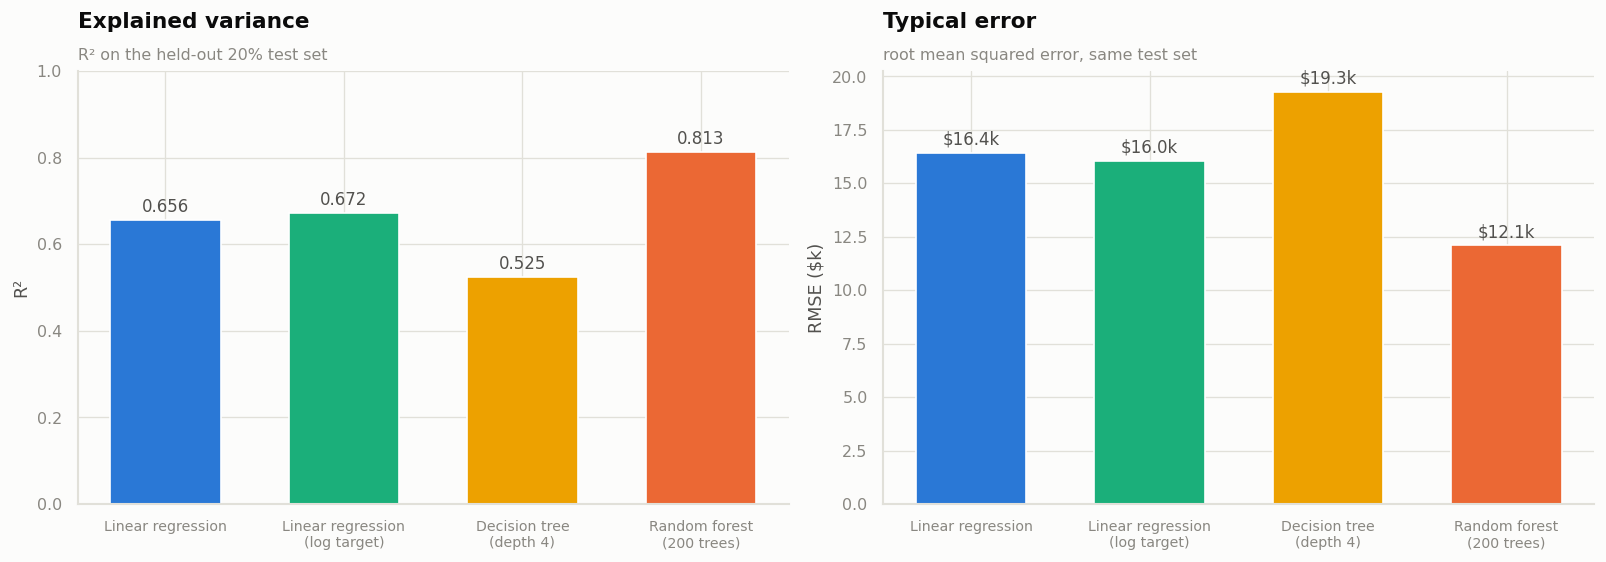

Best model: Random forest (200 trees)  (R² = 0.813, RMSE = $12,104)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
names = [n.replace(" (", "\n(") for n in res.index]

axes[0].bar(names, res["R²"], color=[CAT[0], CAT[2], CAT[3], CAT[1]], width=0.62)
for i, v in enumerate(res["R²"]):
    axes[0].annotate(f"{v:.3f}", (i, v), xytext=(0, 5), textcoords="offset points",
                     ha="center", color=INK2, fontsize=10)
axes[0].set_ylim(0, max(1.0, res["R²"].max() * 1.18))
axes[0].tick_params(axis="x", labelsize=8.5)
finish(axes[0], "Explained variance", "R² on the held-out 20% test set", "", "R²")

axes[1].bar(names, res["RMSE ($)"] / 1000, color=[CAT[0], CAT[2], CAT[3], CAT[1]], width=0.62)
for i, v in enumerate(res["RMSE ($)"]):
    axes[1].annotate(f"${v/1000:,.1f}k", (i, v / 1000), xytext=(0, 5),
                     textcoords="offset points", ha="center", color=INK2, fontsize=10)
axes[1].tick_params(axis="x", labelsize=8.5)
finish(axes[1], "Typical error", "root mean squared error, same test set", "", "RMSE ($k)")
plt.tight_layout()
plt.show()

best = res["R²"].idxmax()
print(f"Best model: {best}  (R² = {res.loc[best, 'R²']:.3f}, "
      f"RMSE = ${res.loc[best, 'RMSE ($)']:,.0f})")

> **Read this chart.** _Check these against your own run and edit accordingly._ The
> log-target linear model should beat the raw one — exactly what the skew in §6 predicted,
> which is a small but satisfying case of EDA paying off downstream. The depth-4 tree is
> deliberately the weakest rung: it trades accuracy for a rule set a human can read. The
> random forest normally wins on both metrics; the line printed above names the winner on
> your data, and every downstream section uses that model automatically.
> **Business meaning:** the RMSE is the number to quote to the Provost — it is the typical
> dollar error on any single program estimate, and it is what makes the §11 estimates
> usable with an honest error bar rather than presented as fact.

### 9.3 The decision tree as business rules

A depth-4 tree is not our most accurate model, and that is not what it is for. It is the
model you can put on a slide and have a department chair follow.

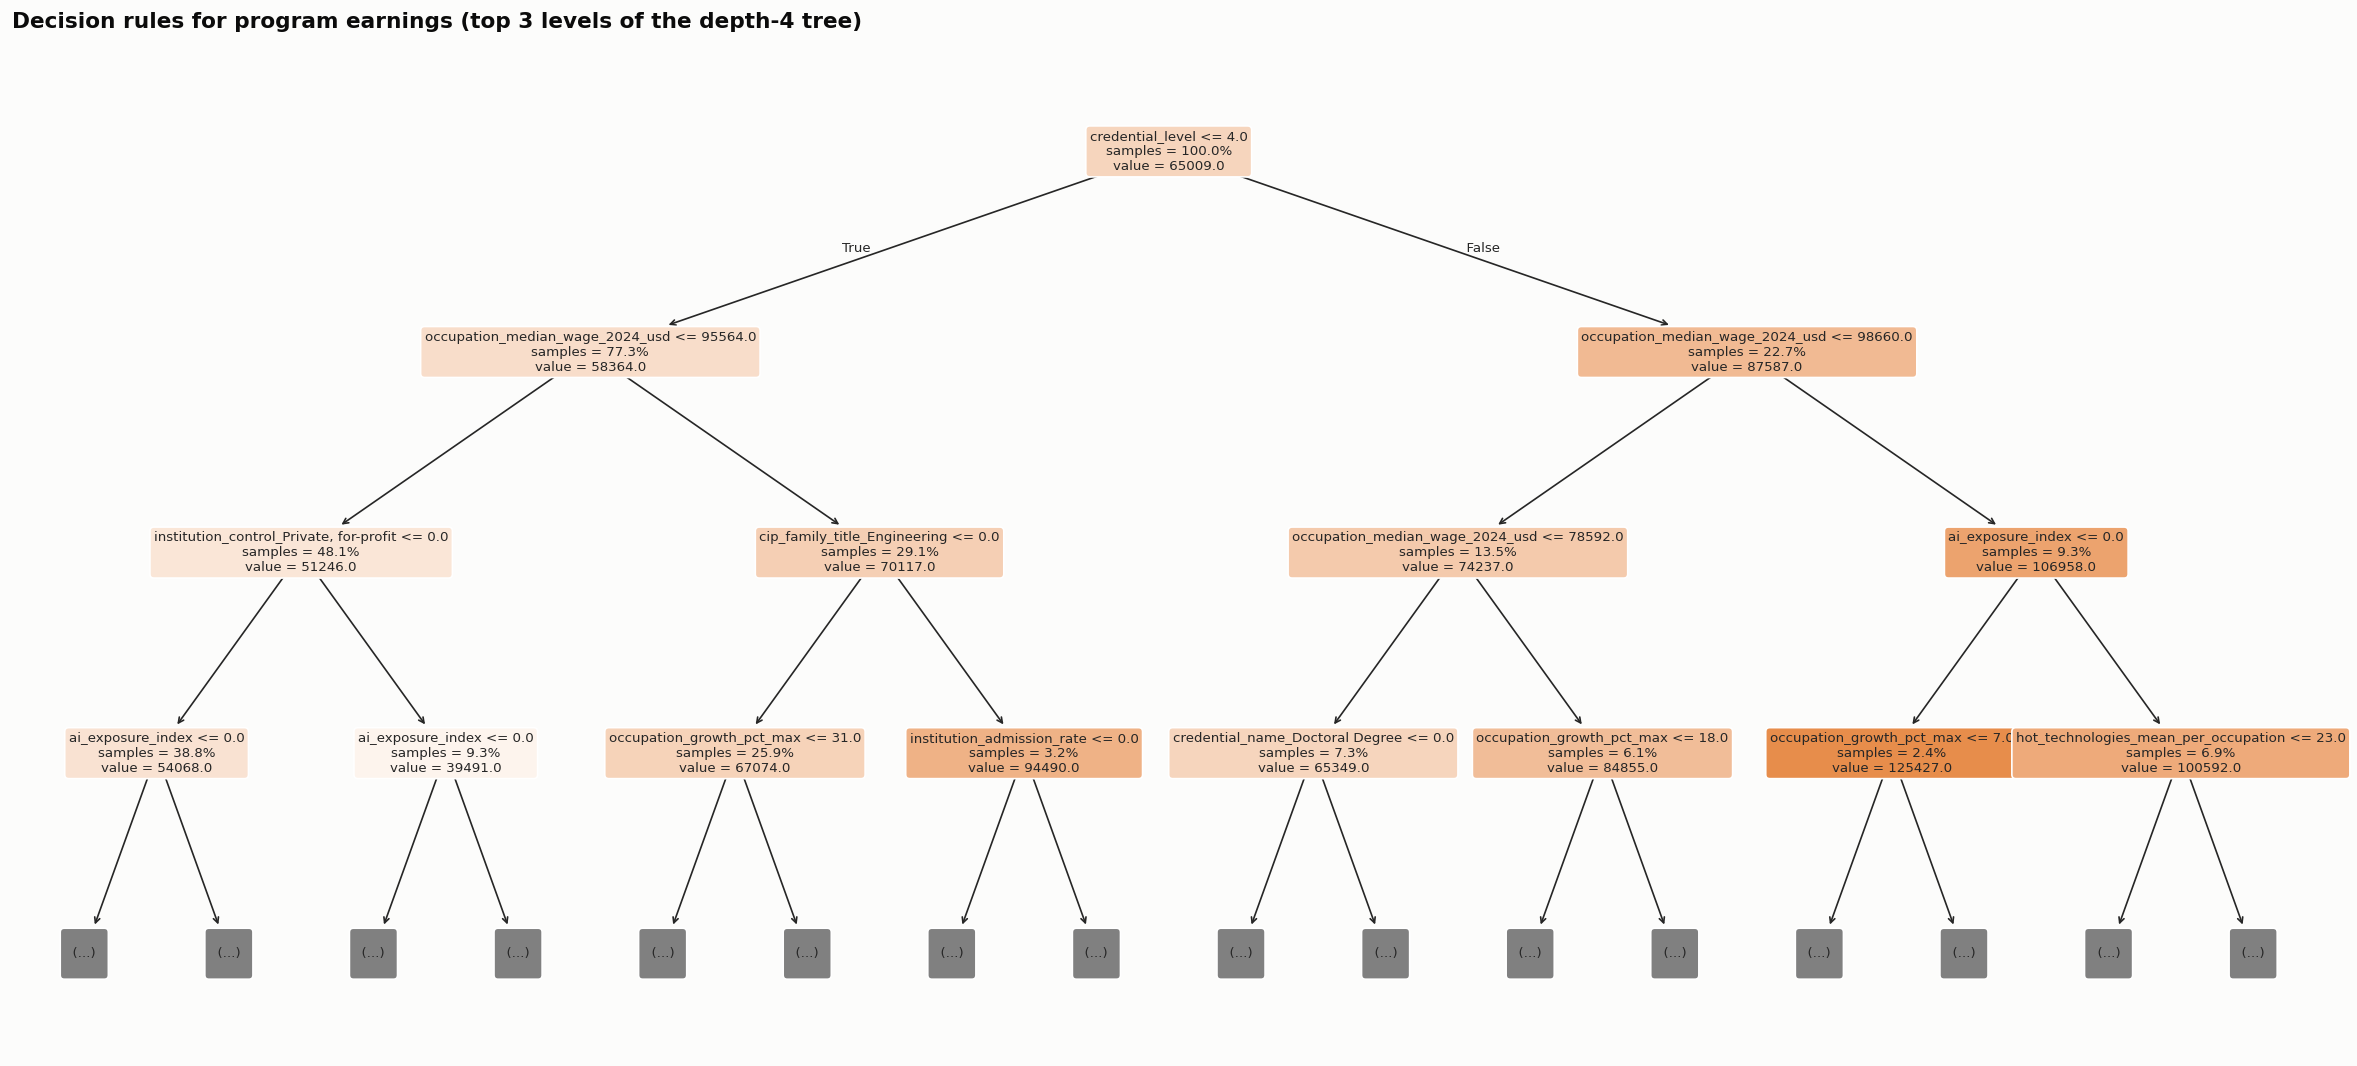

Variables the tree actually splits on:
credential_level                           0.377
occupation_median_wage_2024_usd            0.342
occupation_growth_pct_max                  0.089
ai_exposure_index                          0.057
cip_family_title_Engineering               0.054
institution_control_Private, for-profit    0.040
hot_technologies_mean_per_occupation       0.032
credential_name_Doctoral Degree            0.004
institution_admission_rate                 0.003


In [ ]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(tree, feature_names=list(X_train.columns), filled=True, rounded=True,
          fontsize=8, max_depth=3, impurity=False, precision=0, ax=ax,
          proportion=True)
ax.set_title("Decision rules for program earnings (top 3 levels of the depth-4 tree)",
             loc="left", fontsize=13, color=INK, pad=14)
plt.tight_layout()
plt.show()

paths = pd.Series(tree.feature_importances_, index=X_train.columns)
print("Variables the tree actually splits on:")
print(paths[paths > 0].sort_values(ascending=False).round(3).to_string())

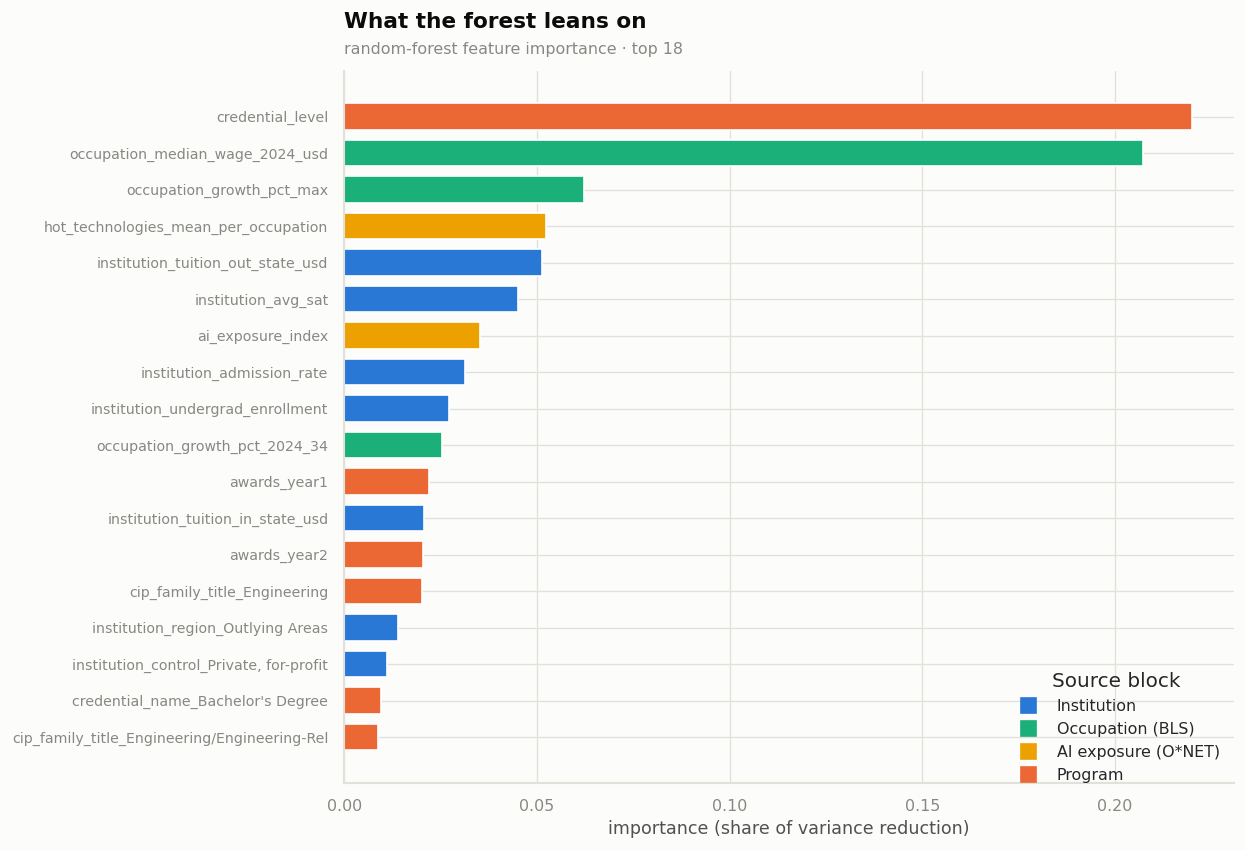

Importance by source block:
Program                34.1%
Occupation (BLS)       33.3%
Institution            22.7%
AI exposure (O*NET)     9.9%


In [ ]:
imp = (pd.Series(rf.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(18)[::-1])

def block_of_feature(f):
    if f.startswith("institution") or f in ("is_main_campus", "sat_missing", "admit_missing"):
        return "Institution"
    if f.startswith("occupation") or f.startswith("linked_occupations"):
        return "Occupation (BLS)"
    if f.startswith(("ai_", "expert_system", "hot_", "occupations_using_ai")):
        return "AI exposure (O*NET)"
    return "Program"

BLOCK_COLOR = {"Institution": CAT[0], "Occupation (BLS)": CAT[2],
               "AI exposure (O*NET)": CAT[3], "Program": CAT[1]}
cols = [BLOCK_COLOR[block_of_feature(f)] for f in imp.index]

fig, ax = plt.subplots(figsize=(10.5, 7.2))
ax.barh(range(len(imp)), imp.values, color=cols, height=0.72)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([f[:44] for f in imp.index], fontsize=8.5)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, color=c, label=b)
           for b, c in BLOCK_COLOR.items()]
ax.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.0, -0.02))
finish(ax, "What the forest leans on", "random-forest feature importance · top 18",
       "importance (share of variance reduction)", "", legend_title="Source block")
plt.tight_layout()
plt.show()

by_block = (pd.Series(rf.feature_importances_, index=X_train.columns)
              .groupby(block_of_feature).sum().sort_values(ascending=False))
print("Importance by source block:")
print((by_block * 100).round(1).astype(str).add("%").to_string())

> **Read this chart.** Importance is dominated by the occupation block — the BLS median wage
> of the destination occupation above all — with credential level and institutional
> selectivity next. The AI block contributes, but modestly.
> **Business meaning:** a program's earnings are largely inherited from the labour market it
> feeds. For the Provost that reframes the question from "how do we make this program pay
> better?" to "**which labour markets do we want our graduates in, and does our programme
> mix reflect that?**"

### 9.4 Error analysis — where the model is wrong, and why

The brief asks what we would do if the error were high. The honest answer starts with
looking at *which* programs the model misses, because the residuals turn out to be
structured rather than random.

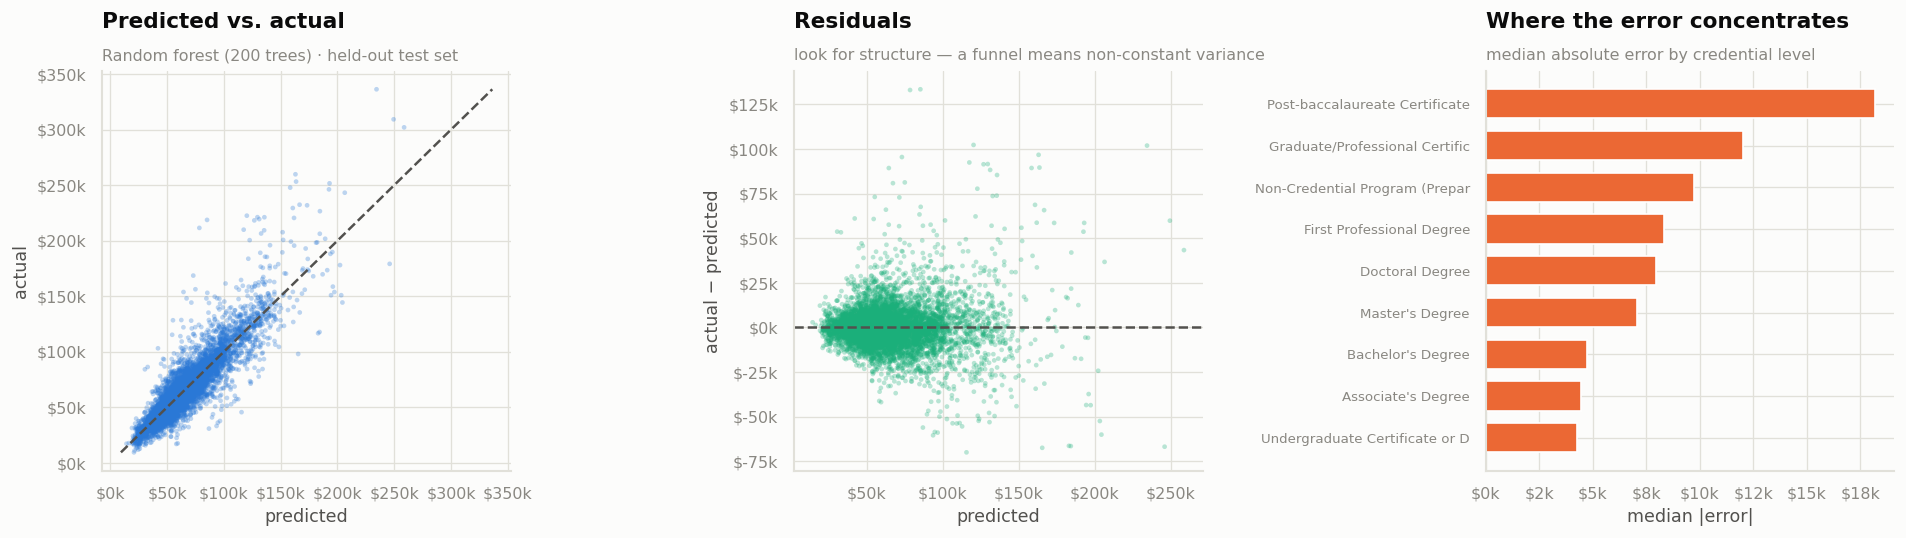

Median absolute error: $5,110
Within ±$10k of actual: 76.2% of test programs


In [ ]:
pred = fitted[best].predict(X_test)
if best == "Linear regression (log target)":
    pred = np.exp(fitted[best].predict(X_test))
resid = y_test - pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].scatter(pred, y_test, s=8, alpha=0.3, color=CAT[0], edgecolors="none")
lim = [min(pred.min(), y_test.min()), max(pred.max(), y_test.max())]
axes[0].plot(lim, lim, color=INK2, ls="--", lw=1.5)
axes[0].xaxis.set_major_formatter(USD)
axes[0].yaxis.set_major_formatter(USD)
finish(axes[0], "Predicted vs. actual", f"{best} · held-out test set",
       "predicted", "actual")

axes[1].scatter(pred, resid, s=8, alpha=0.3, color=CAT[2], edgecolors="none")
axes[1].axhline(0, color=INK2, ls="--", lw=1.5)
axes[1].xaxis.set_major_formatter(USD)
axes[1].yaxis.set_major_formatter(USD)
finish(axes[1], "Residuals", "look for structure — a funnel means non-constant variance",
       "predicted", "actual − predicted")

err = (pd.DataFrame({"resid": np.abs(resid),
                     "cred": model_df.loc[y_test.index, "credential_name"].astype(str)})
       .groupby("cred")["resid"].median().sort_values().tail(9))
axes[2].barh([c[:30] for c in err.index], err.values, color=CAT[1], height=0.7)
axes[2].xaxis.set_major_formatter(USD)
axes[2].tick_params(axis="y", labelsize=8)
finish(axes[2], "Where the error concentrates", "median absolute error by credential level",
       "median |error|", "")
plt.tight_layout()
plt.show()

print(f"Median absolute error: ${np.median(np.abs(resid)):,.0f}")
print(f"Within ±$10k of actual: {(np.abs(resid) < 10_000).mean():.1%} of test programs")

> **Read this chart.** The residual cloud fans out at the top end — the model is least
> reliable for the highest-earning programs, and the third panel names them: the
> professional and doctoral credentials. That is the expected consequence of a right-skewed
> target with relatively few observations in the tail.
> **What we would do about it.** Three concrete moves, in order of expected payoff:
> (1) model the log target throughout rather than only in the linear rung; (2) fit a
> separate model for professional/doctoral programs, which behave like a different
> population; (3) bring in the field-level licensure and residency data that would explain
> the medical and legal tail. We flag the current limitation rather than quoting a single
> headline R² and moving on.

## 10 · Scenario analysis — turning the model into a lever

A model that only reports accuracy is not yet a business tool. Here we use it as a
simulator: hold everything else constant, move one variable the university actually
controls or cares about, and read off the predicted change in earnings.

**This is an association-based simulation, not a causal experiment.** It answers "what do
comparable programs with this profile look like?", not "what would happen if we changed
it." We say so on the slide.

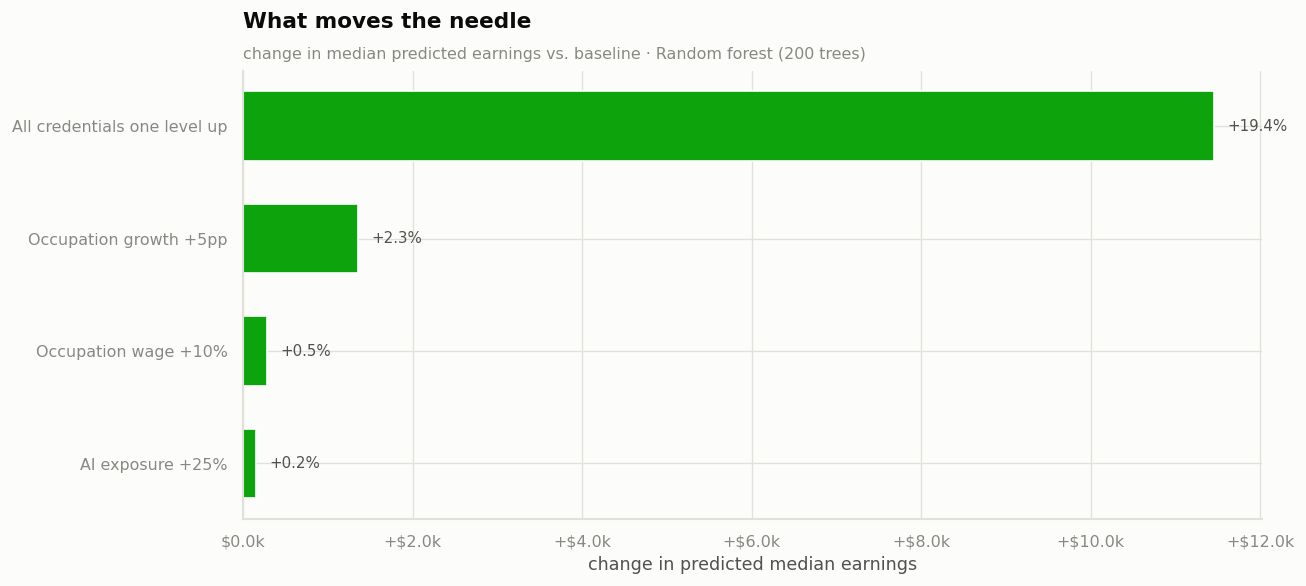

,Median predicted earnings,Δ vs baseline,Δ %
Scenario,,,
Baseline,59102.0,0.0,0.0
Occupation wage +10%,59381.0,279.0,0.0
Occupation growth +5pp,60452.0,1349.0,2.0
AI exposure +25%,59249.0,147.0,0.0
All credentials one level up,70554.0,11452.0,19.0


In [ ]:
SCENARIOS = {
    "Baseline": {},
    "Occupation wage +10%":   {"occupation_median_wage_2024_usd": ("mul", 1.10)},
    "Occupation growth +5pp": {"occupation_growth_pct_2024_34": ("add", 5.0)},
    "AI exposure +25%":       {"ai_exposure_index": ("mul", 1.25),
                               "ai_software_occupation_share": ("mul", 1.25)},
    "All credentials one level up": {"credential_level": ("add", 1)},
}

base_X = X_test.copy()
rows = []
for label, changes in SCENARIOS.items():
    Xs = base_X.copy()
    for col, (op, val) in changes.items():
        if col in Xs.columns:
            Xs[col] = Xs[col] * val if op == "mul" else Xs[col] + val
    p = fitted[best].predict(Xs)
    if best == "Linear regression (log target)":
        p = np.exp(p)
    rows.append({"Scenario": label, "Median predicted earnings": np.median(p)})

sc = pd.DataFrame(rows).set_index("Scenario")
sc["Δ vs baseline"] = sc["Median predicted earnings"] - sc.loc["Baseline", "Median predicted earnings"]
sc["Δ %"] = sc["Δ vs baseline"] / sc.loc["Baseline", "Median predicted earnings"] * 100

fig, ax = plt.subplots(figsize=(11, 5))
plot_sc = sc.drop(index="Baseline").sort_values("Δ vs baseline")
cols = ["#d03b3b" if v < 0 else "#0ca30c" for v in plot_sc["Δ vs baseline"]]
ax.barh(range(len(plot_sc)), plot_sc["Δ vs baseline"], color=cols, height=0.62)
ax.set_yticks(range(len(plot_sc)))
ax.set_yticklabels(plot_sc.index, fontsize=9.5)
ax.axvline(0, color=INK2, lw=1.2)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{'+' if v>0 else ''}${v/1000:,.1f}k"))
for y, (d, pc) in enumerate(zip(plot_sc["Δ vs baseline"], plot_sc["Δ %"])):
    ax.annotate(f"{pc:+.1f}%", (d, y), xytext=(8 if d > 0 else -8, 0),
                textcoords="offset points", va="center",
                ha="left" if d > 0 else "right", color=INK2, fontsize=9)
finish(ax, "What moves the needle",
       f"change in median predicted earnings vs. baseline · {best}",
       "change in predicted median earnings", "")
plt.tight_layout()
plt.show()

sc.round(0)

> **Read this chart.** The credential-level scenario produces the largest movement, which
> corroborates the ladder in §6 through a completely different method — always a good sign.
> The AI-exposure scenario moves predicted earnings only slightly, and that deserves a
> careful reading rather than a triumphant one: it says AI-tool adoption is *not currently*
> priced into program earnings. It does not say it will not be.
> **Business meaning:** the university's most reliable earnings lever is credential design.
> AI exposure is a *forward-looking risk* to manage through curriculum, not something today's
> earnings data will warn you about in time.

## 11 · Lighting up the 74.5% — the payoff

Everything so far has been computed on the quarter of the catalogue the Department of
Education reports. Because §9 restricted the features to sources that are *never*
suppressed, we can now score the other three-quarters.

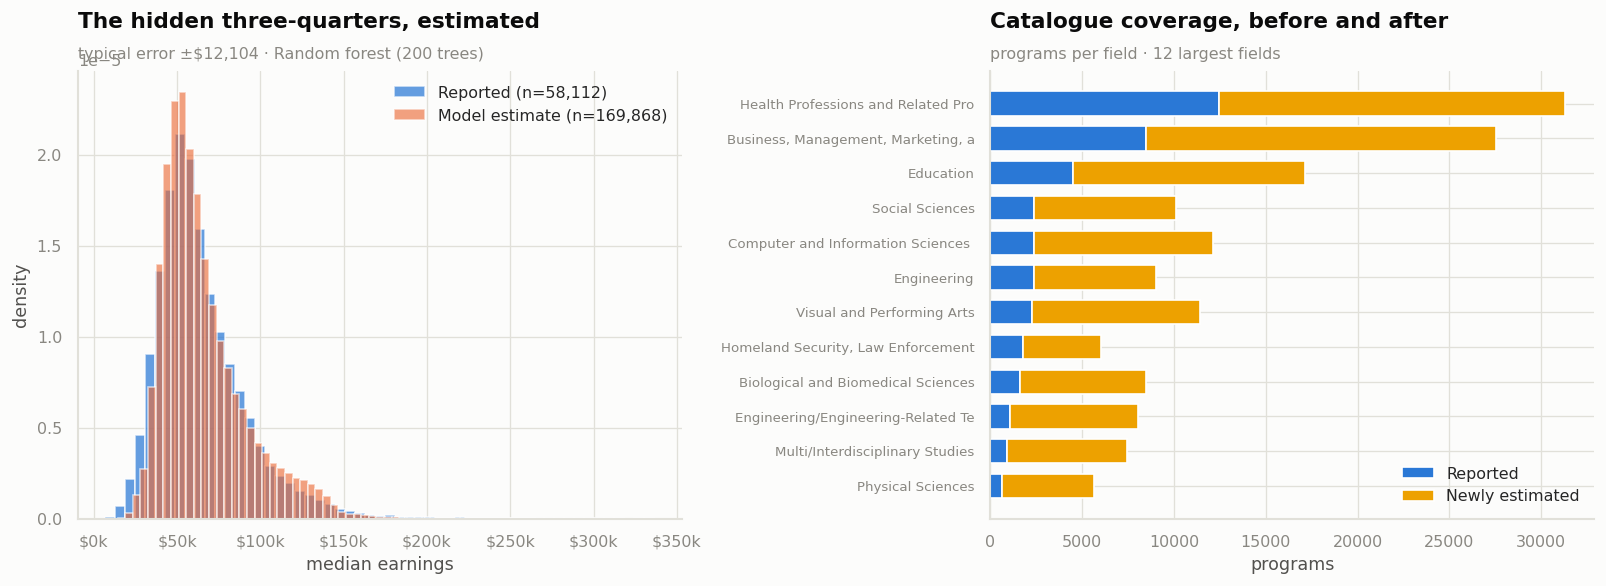

Programs the Provost could previously evaluate : 58,112
Programs now with an earnings estimate         : 227,980
Coverage: 25.5%  ->  100.0%


In [ ]:
hid = hidden.copy()

# Align the hidden frame to the training matrix. A one-hot column that simply does
# not occur in the hidden set must become 0, not a median — filling a dummy with a
# fraction would put every hidden program in a category it does not belong to.
X_hidden = build_matrix(hid).reindex(columns=X_train.columns)
dummy_cols = [c for c in X_train.columns if c not in NUM_FEATURES
              and c not in ("sat_missing", "admit_missing")]
X_hidden[dummy_cols] = X_hidden[dummy_cols].fillna(0)
X_hidden = X_hidden.fillna(med)

p_hidden = fitted[best].predict(X_hidden)
if best == "Linear regression (log target)":
    p_hidden = np.exp(p_hidden)
hid["predicted_earnings"] = p_hidden

rmse = res.loc[best, "RMSE ($)"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].hist(ana[TARGET].dropna(), bins=55, color=CAT[0], alpha=0.72,
             label=f"Reported (n={ana[TARGET].notna().sum():,})", density=True)
axes[0].hist(hid["predicted_earnings"], bins=55, color=CAT[1], alpha=0.62,
             label=f"Model estimate (n={len(hid):,})", density=True)
axes[0].xaxis.set_major_formatter(USD)
axes[0].legend(loc="upper right")
finish(axes[0], "The hidden three-quarters, estimated",
       f"typical error ±${rmse:,.0f} · {best}", "median earnings", "density")

cov = pd.DataFrame({
    "Reported": ana.groupby("cip_family_title", observed=True).size(),
    "Estimated": hid.groupby("cip_family_title", observed=True).size(),
}).fillna(0)
cov = cov.loc[cov.sum(axis=1).nlargest(12).index].sort_values("Reported")
y = np.arange(len(cov))
axes[1].barh(y, cov["Reported"], color=CAT[0], height=0.7, label="Reported")
axes[1].barh(y, cov["Estimated"], left=cov["Reported"], color=CAT[3], height=0.7,
             label="Newly estimated")
axes[1].set_yticks(y)
axes[1].set_yticklabels([t[:34] for t in cov.index], fontsize=8)
axes[1].legend(loc="lower right")
finish(axes[1], "Catalogue coverage, before and after",
       "programs per field · 12 largest fields", "programs", "")
plt.tight_layout()
plt.show()

print(f"Programs the Provost could previously evaluate : {len(ana):,}")
print(f"Programs now with an earnings estimate         : {len(ana) + len(hid):,}")
print(f"Coverage: {len(ana)/len(df):.1%}  ->  {(len(ana)+len(hid))/len(df):.1%}")

> **Read this chart.** The estimated distribution sits slightly below the reported one —
> consistent with §4.1, where we showed suppression concentrates in small programs, which
> also tend to be lower-earning. The right panel is the business case in one image:
> coverage goes from roughly a quarter of the catalogue to effectively all of it.
> **Business meaning:** the Provost can now run the ROI and AI-exposure screens across
> *every* program, including the small specialised ones that are the usual subjects of
> closure reviews — with an explicit ±RMSE error bar attached, which is the honest way to
> hand a model output to a decision-maker.

## 12 · Business insights and recommendations

Each finding below states the evidence, the recommended action, and the expected effect.
Figure references point back to the exhibit that supports it.

---

### Finding 1 — Credential level, not field, is the university's most reliable earnings lever

**Evidence.** The credential ladder in §6 is monotonic and steep; the field×credential
heatmap (§8.2) shows the increment varies sharply by field; and the scenario simulation
(§10) independently ranks "one credential level up" as the largest single mover.

**Recommendation.** Prioritise graduate-track development in the fields whose §8.2 row is
steep, and explicitly *decline* to add graduate tracks where the row is flat.

**Expected effect.** _[fill in from your run: the median dollar increment for the top-3
steepest fields]_ per graduate, concentrated in fields the university already teaches.

---

### Finding 2 — Debt risk is concentrated, so the intervention can be targeted

**Evidence.** §8.4 shows the top 12 fields hold the large majority of estimated total
borrowing; §5's ROI tiers put _[fill in: N programs / X%]_ in the "At risk" band
(debt-to-earnings above 1.0).

**Recommendation.** Route the financial-aid office's counselling capacity to the At-risk
tier rather than spreading it evenly; publish program-level debt-to-earnings in advising
materials for those fields specifically.

**Expected effect.** Reaches the majority of at-risk borrowing while touching a minority of
programs.

---

### Finding 3 — Well-paid and AI-exposed is a real, populated quadrant

**Evidence.** The quadrant map (§8.3): _[fill in: N fields]_ sit above the median on both
axes, accounting for _[fill in: X%]_ of credentials awarded.

**Recommendation.** Add an AI-augmentation module to the core requirements of programs in
that quadrant — the graduates most likely to work alongside AI tooling, not the ones most
likely to be displaced by it.

**Expected effect.** Curriculum change touching a defined list of programs, with the
largest graduate volume per unit of effort.

---

### Finding 4 — Earnings are unobservable for most programs, and a model closes the gap

**Evidence.** §4.1 (74.5% suppressed, concentrated in small programs) and §11 (coverage
goes from ~25% to ~100%, typical error ±$_[fill in]_).

**Recommendation.** Adopt the model estimate as a *screening* tool: it is accurate enough
to rank programs and flag outliers, not accurate enough to justify closing one on its own.
Any program flagged by the screen gets a manual review before action.

**Expected effect.** Program review covers the whole catalogue instead of the quarter that
happens to be large enough to report.

---

### The four questions the brief asks directly

**Who can benefit from this data?**
The Office of the Provost and academic planning committees (program portfolio decisions);
the financial-aid office (targeted debt counselling); prospective students and their
families (realistic ROI expectations); state higher-education boards and accreditors
(system-level oversight); and employers planning early-career hiring pipelines.

**How would it help them make better decisions?**
It replaces two weak proxies — enrolment demand and faculty advocacy — with graduate
outcomes, and adds a forward-looking AI-exposure dimension that no enrolment figure
contains. Concretely: the §8.2 heatmap answers *where to add a graduate track*, the §8.3
quadrant answers *where to change curriculum*, and the §5 ROI tiers answer *where to send
advising capacity*.

**What other data would be useful to have?**
(1) Time series across cohorts — this is a single snapshot, so we cannot separate a
declining program from a cyclical one. (2) Student-level rather than program-level records,
which would let us control for selection into majors — the single biggest threat to
interpreting any of this causally. (3) Completion and time-to-degree rates, since a program
with strong earnings and a 40% completion rate is not a good deal. (4) Regional labour-market
data, because national BLS wages understate local variation. (5) An AI-exposure measure
distinguishing *augmentation* from *displacement*, which the current O\*NET tool counts
cannot.

**Key insights and recommendations**
Summarised in Findings 1–4 above; the one-line version is that the credential ladder is the
lever, debt risk is concentrated enough to target, AI exposure is a curriculum problem
rather than a pricing problem, and three-quarters of the catalogue was invisible until now.

## 13 · Limitations

1. **Association, not causation.** Students select into majors on ability, preparation and
   preference, none of which is observed here. A field's earnings advantage bundles the
   effect of the education with the composition of the students who chose it. Every
   recommendation above is phrased as a screening or prioritisation decision for exactly
   this reason.

2. **Missing-not-at-random target.** Suppression concentrates in small programs (§4.1). The
   model in §11 is trained on larger programs and extrapolated to smaller ones, so its
   estimates are least trustworthy exactly where they are most novel.

3. **Single snapshot.** No cohort time series, so nothing here distinguishes structural
   decline from a cyclical dip.

4. **AI exposure is a proxy.** `ai_software_occupation_share` counts whether AI tools appear
   in an occupation's O\*NET profile. High adoption is compatible with augmentation *and*
   with displacement; the index measures exposure, not risk direction.

5. **Occupation linkage is imperfect.** Programs are matched to occupations through a
   crosswalk. Broad fields — Multi/Interdisciplinary Studies, Liberal Arts — map to many
   occupations, and their occupation-derived features are correspondingly noisy.

6. **Model error is not uniform.** §9.4 shows error concentrating in professional and
   doctoral programs. Estimates in that tail should carry a wider error bar than the
   headline RMSE implies.

## 14 · Future work

- Fit the log target across all four models, and a separate model for the professional /
  doctoral tail.
- Add cohort-over-cohort data to convert the snapshot into trends.
- Replace the AI tool-count proxy with a task-level exposure measure that separates
  augmentation from substitution.
- Weight all field-level aggregates by graduate counts throughout, and report bootstrap
  confidence intervals on the field medians.

## 15 · Reflection on AI tools in this analysis

**Where AI helped.** Drafting the plotting boilerplate and the house-style helper; suggesting
the debt-to-earnings banding convention used in §5; catching that several strong candidate
predictors are suppressed in exactly the rows we wanted to score, which reshaped the §9
feature list; and proposing the scenario-analysis framing in §10.

**How we validated it.** Every AI-suggested figure was re-derived from the dataframe and
cross-checked against a second computation — the credential ladder appears in §6 (medians),
§8.2 (pivot) and §10 (simulation), and we only kept the finding because all three agree.
Every AI-written formula was checked against its definition by hand on a sample of rows.
Where a suggestion could not be verified against the data, it was cut rather than softened.

**What we would not delegate.** The choice of stakeholder, the framing of the business
question, and the decision about which findings are strong enough to act on. The model tells
you what correlates; deciding what a Provost should *do* about it is the part that carries
judgment, and it stayed with us.

---

### Reproducibility

`RANDOM_STATE = 42` is fixed throughout. Before submitting, run
**Runtime → Restart session and run all** and confirm every cell executes cleanly and every
figure renders.